# TF-IDF, 토큰화 작업->최종 단어 벡터화

In [ ]:
import pandas as pd
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer

# --- 1. 데이터 준비 (이전과 동일) ---
normal_file = "normal_컬럼정리.csv"
phishing_file = "phishing_total_컬럼정리.csv"

try:
    df_normal = pd.read_csv(normal_file)
    df_phishing = pd.read_csv(phishing_file)
    df_total = pd.concat([df_normal, df_phishing], ignore_index=True)

    if "script" in df_total.columns:
        df_total = df_total.rename(columns={"script": "text"})
    df_total["text"] = df_total["text"].fillna("")

    print("데이터 로드 및 통합 완료!")
    print(f"전체 데이터 수: {len(df_total)}건")
    print("-" * 50)
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다. ({e})")


# --- 2. Kiwi 형태소 분석기 준비 (이전과 동일) ---
kiwi = Kiwi()
kiwi.add_user_word("대환대출", "NNG")
kiwi.add_user_word("금융감독원", "NNG")


def kiwi_tokenizer(text):
    result = kiwi.analyze(text)
    tokens = [
        token.lemma for token in result[0][0] if token.tag in ["NNG", "NNP", "VV", "VA"]
    ]
    return tokens


# --- 2-1. 토큰화 결과 저장 (추가된 부분) ---
# .apply()를 사용해 모든 'text' 행에 대해 kiwi_tokenizer 함수를 실행하고
# 그 결과를 'tokens'라는 새로운 컬럼에 저장
print("각 텍스트를 토큰화하여 'tokens' 컬럼에 저장하는 중... (시간이 걸릴 수 있습니다)")
df_total["tokens"] = df_total["text"].apply(kiwi_tokenizer)
print("토큰화 및 저장 완료!")
print("토큰화 결과 샘플:")
print(df_total[["text", "tokens"]].head())
print("-" * 50)


# --- 3. TF-IDF 벡터화 및 계산 (이전과 동일) ---
# 여기서는 lambda 함수를 이용해 이미 만들어진 'tokens' 컬럼을 바로 사용
# 이렇게 하면 매번 토큰화를 다시 하지 않아도 되어서 효율적임
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,  # 이미 토큰화된 리스트를 그대로 사용
    preprocessor=lambda x: x,
    min_df=5,
    max_df=0.95,
)
X_tfidf = tfidf_vectorizer.fit_transform(df_total["tokens"])
print("\nTF-IDF 행렬 생성 완료!")
print(f"생성된 단어(피처) 수: {X_tfidf.shape[1]}개")
print("-" * 50)


# --- 4. 결과 분석 (이전과 동일) ---
def get_top_tfidf_keywords(tfidf_matrix, labels, class_label, top_n=20):
    class_rows = tfidf_matrix[(labels == class_label).values]
    mean_scores = class_rows.mean(axis=0).A1
    feature_names = tfidf_vectorizer.get_feature_names_out()
    df_scores = pd.DataFrame({"term": feature_names, "score": mean_scores})
    return df_scores.sort_values(by="score", ascending=False).head(top_n)


top_keywords_normal = get_top_tfidf_keywords(X_tfidf, df_total["is_phishing"], 0)
top_keywords_phishing = get_top_tfidf_keywords(X_tfidf, df_total["is_phishing"], 1)

print("\n--- '정상 통화' 핵심 키워드 (Top 20) ---")
print(top_keywords_normal)
print("\n---'보이스피싱' 핵심 키워드 (Top 20) ---")
print(top_keywords_phishing)
print("-" * 50)


# --- 5. 최종 데이터 저장 (추가된 부분) ---
output_filename = "total_data_with_tokens.csv"
# index=False 옵션은 불필요한 인덱스 컬럼 저장을 방지
df_total.to_csv(output_filename, index=False, encoding="utf-8-sig")
print(
    f"\n성공! 토큰화된 결과가 포함된 전체 데이터가 '{output_filename}' 파일로 저장되었습니다."
)

데이터 로드 및 통합 완료!
전체 데이터 수: 397539건
--------------------------------------------------
각 텍스트를 토큰화하여 'tokens' 컬럼에 저장하는 중... (시간이 걸릴 수 있습니다)
토큰화 및 저장 완료!
토큰화 결과 샘플:
                                                text  \
0  엄마, 저 오늘 정말 신기한 일 있었어요! 제가 오늘 집에 오는 길에 누구를 만났는...   
1            누구를 만났길래 그렇게 신이 났니? 엄마도 아는 사람일까? 궁금하구나.   
2                          민지라고 기억하세요? 저랑 친했던 친구였어요.   
3  어머, 초등학교 3학년 때 같은 반했던 친구 아니니? 우리 집에도 놀러 왔던 걸로 ...   
4          네, 맞아요! 민지도 엄마를 기억하더라고요. 잘 지내시냐고 안부 물었어요.   

                                            tokens  
0             [엄마, 신기하다, 일, 있다, 집, 오다, 길, 만나다, 알다]  
1                   [만나다, 신, 나다, 엄마, 알다, 사람, 궁금하다]  
2                                [민지, 기억, 친하다, 친구]  
3  [초등학교, 학년, 때, 같다, 반, 친구, 집, 놀다, 오다, 기억, 맞다, 이름]  
4                        [맞다, 민지, 엄마, 기억, 지내다, 안부]  
--------------------------------------------------


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



TF-IDF 행렬 생성 완료!
생성된 단어(피처) 수: 8809개
--------------------------------------------------

--- '정상 통화' 핵심 키워드 (Top 20) ---
      term     score
8276    하다  0.049686
2132    되다  0.048106
140     감사  0.043540
8669    확인  0.030991
4873    알다  0.029156
6239    있다  0.025277
784     교재  0.022582
8719    회원  0.021343
8683    환불  0.019923
2192   드리다  0.018111
2497    말씀  0.018013
2515    맞다  0.016121
1045  기다리다  0.015950
214     같다  0.014965
408     결제  0.014422
7576    취소  0.012619
5087    없다  0.012511
22      가능  0.012451
940    그러다  0.012066
6564    전화  0.011935

---'보이스피싱' 핵심 키워드 (Top 20) ---
     term     score
4873   알다  0.044528
8276   하다  0.039646
6239   있다  0.034867
2132   되다  0.031859
5087   없다  0.025692
2497   말씀  0.024820
8669   확인  0.022802
2192  드리다  0.022614
2515   맞다  0.022543
3358   본인  0.022351
518    고객  0.021284
510    계좌  0.019867
7919   통장  0.015778
6564   전화  0.015698
6120    일  0.015263
5215   연락  0.014638
5787   은행  0.013636
214    같다  0.012702
2676  모르다  0.012262
7174 

# LightGBM 성능 테스트

In [ ]:
import pandas as pd
import ast  # 문자열로 저장된 리스트를 실제 리스트로 변환하기 위해 필요
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- 1. 데이터 로드 및 준비 ---

input_file = "total_data_with_tokens.csv"
try:
    df = pd.read_csv(input_file)

    # 중요: CSV에 저장된 'tokens' 컬럼은 문자열 형태이므로,
    # ast.literal_eval을 사용해 실제 리스트(list) 형태로 변환해줘야 함
    df["tokens"] = df["tokens"].apply(ast.literal_eval)

    print("데이터 로드 및 'tokens' 컬럼 변환 완료!")
    print("-" * 50)

except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    exit()  # 파일이 없으면 실행 중지


# --- 2. TF-IDF 벡터화 ---
# 이전과 동일하게 TF-IDF 행렬을 생성
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x, preprocessor=lambda x: x, min_df=5, max_df=0.95
)
X_tfidf = tfidf_vectorizer.fit_transform(df["tokens"])
y = df["is_phishing"]

print("TF-IDF 행렬 생성 완료!")
print(f"전체 단어(피처) 수: {X_tfidf.shape[1]}개")
print("-" * 50)


# --- 3. 핵심 키워드 선별 (Feature Selection) ---

# 카이제곱(chi2) 통계량을 사용해 가장 관련성 높은 특성(단어)을 선택
# k=300: 가장 중요한 키워드 300개를 선택하겠다는 의미 (이 값은 조절 가능)
selector = SelectKBest(score_func=chi2, k=300)

# TF-IDF 행렬과 라벨을 넣고, selector를 학습시켜 중요한 특성만 남김
X_selected = selector.fit_transform(X_tfidf, y)

# 선택된 단어들이 무엇인지 확인
selected_indices = selector.get_support(indices=True)
all_feature_names = tfidf_vectorizer.get_feature_names_out()
selected_feature_names = all_feature_names[selected_indices]

print("--- 3. 핵심 키워드 선별 완료 ---")
print(f"선별된 핵심 키워드 수: {X_selected.shape[1]}개")
print("선별된 키워드 샘플 (앞 20개):")
print(list(selected_feature_names[:20]))
print("-" * 50)


# --- 4. 훈련/테스트 데이터 분리 ---

# 선택된 특징 행렬(X_selected)을 사용해 데이터를 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y  # 라벨 비율 유지
)

print("--- 4. 훈련/테스트 데이터 분리 완료 ---")
print(f"훈련 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")
print("-" * 50)


# --- 5. LightGBM 모델 훈련 ---

# 클래스 불균형 처리를 위한 가중치 계산
# (정상 라벨 수) / (피싱 라벨 수) -> 소수 클래스(피싱)에 더 많은 가중치를 줌
label_counts = y.value_counts()
scale_pos_weight = label_counts[0] / label_counts[1]

# LGBM 모델 객체 생성
lgbm = LGBMClassifier(
    objective="binary",  # 이진 분류 문제
    scale_pos_weight=scale_pos_weight,  # 클래스 불균형 처리
    random_state=42,
)

# 모델 훈련
lgbm.fit(X_train, y_train)

print("\n--- 5. LightGBM 모델 훈련 완료 ---")
print("-" * 50)


# --- 6. 모델 성능 평가 ---

# 테스트 데이터로 예측
y_pred = lgbm.predict(X_test)

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(
    y_test, y_pred, target_names=["정상(0)", "피싱(1)"]
)

print("\n--- 6. 최종 모델 성능 평가 결과 ---")
print(f"정확도 (Accuracy): {accuracy:.4f}")

print("\n혼동 행렬 (Confusion Matrix):")
print(conf_matrix)
print("(TN) (FP)")
print("(FN) (TP)")

print("\n상세 평가 지표 (Classification Report):")
print(class_report)

C:\Users\user\AppData\Local\Temp\ipykernel_12772\2215335843.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


데이터 로드 및 'tokens' 컬럼 변환 완료!
--------------------------------------------------


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF 행렬 생성 완료!
전체 단어(피처) 수: 8809개
--------------------------------------------------
--- 3. 핵심 키워드 선별 완료 ---
선별된 핵심 키워드 수: 300개
선별된 키워드 샘플 (앞 20개):
['가능', '가입', '가해자', '감사', '감정', '강의', '강좌', '갚다', '개설', '개인', '거구', '거래', '걱정', '검거', '검사', '검찰', '검찰청', '결제', '경기도', '경찰']
--------------------------------------------------
--- 4. 훈련/테스트 데이터 분리 완료 ---
훈련 데이터 크기: (318031, 300)
테스트 데이터 크기: (79508, 300)
--------------------------------------------------
[LightGBM] [Info] Number of positive: 162639, number of negative: 155392
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.118219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 55159
[LightGBM] [Info] Number of data points in the train set: 318031, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.511394 -> initscore=0.045582
[LightGBM] [Info] Start training from 

c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- 6. 최종 모델 성능 평가 결과 ---
정확도 (Accuracy): 0.7878

혼동 행렬 (Confusion Matrix):
[[33825  5023]
 [11847 28813]]
(TN) (FP)
(FN) (TP)

상세 평가 지표 (Classification Report):
              precision    recall  f1-score   support

       정상(0)       0.74      0.87      0.80     38848
       피싱(1)       0.85      0.71      0.77     40660

    accuracy                           0.79     79508
   macro avg       0.80      0.79      0.79     79508
weighted avg       0.80      0.79      0.79     79508



# Xgboost, 랜덤포레스트 성능 테스트

In [9]:
import pandas as pd
import ast
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- 1. 데이터 로드 및 핵심 키워드 선별 (이전과 동일) ---

input_file = "total_data_with_tokens.csv"
try:
    df = pd.read_csv(input_file)
    df["tokens"] = df["tokens"].apply(ast.literal_eval)
    print("데이터 로드 및 'tokens' 컬럼 변환 완료!")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    exit()

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x, preprocessor=lambda x: x, min_df=5, max_df=0.95
)
X_tfidf = tfidf_vectorizer.fit_transform(df["tokens"])
y = df["is_phishing"]

selector = SelectKBest(score_func=chi2, k=300)
X_selected = selector.fit_transform(X_tfidf, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)
print("데이터 준비 및 분리 완료!")
print("-" * 50)


# --- 2. XGBoost 모델 훈련 및 평가 ---

print("\n--- XGBoost 모델 평가 시작 ---")

# 클래스 불균형 처리를 위한 가중치 계산
label_counts = y.value_counts()
scale_pos_weight_xgb = label_counts[0] / label_counts[1]

# XGBoost 모델 객체 생성 및 훈련
# use_label_encoder=False, eval_metric='logloss'는 경고 메시지를 피하기 위한 옵션
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight_xgb,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
)
xgb_model.fit(X_train, y_train)

# XGBoost 모델 성능 평가
y_pred_xgb = xgb_model.predict(X_test)
print("\n--- XGBoost 최종 모델 성능 평가 결과 ---")
print(f"정확도 (Accuracy): {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\n혼동 행렬 (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n상세 평가 지표 (Classification Report):")
print(classification_report(y_test, y_pred_xgb, target_names=["정상(0)", "피싱(1)"]))
print("-" * 50)


# --- 3. 랜덤 포레스트 모델 훈련 및 평가 ---

print("\n--- 랜덤 포레스트 모델 평가 시작 ---")

# 랜덤 포레스트 모델 객체 생성 및 훈련
# class_weight='balanced' 옵션으로 클래스 불균형을 처리
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100개의 의사결정 나무를 사용
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,  # 모든 CPU 코어를 사용해 학습 속도 향상
)
rf_model.fit(X_train, y_train)

# 랜덤 포레스트 모델 성능 평가
y_pred_rf = rf_model.predict(X_test)
print("\n--- 랜덤 포레스트 최종 모델 성능 평가 결과 ---")
print(f"정확도 (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n혼동 행렬 (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_rf))
print("\n상세 평가 지표 (Classification Report):")
print(classification_report(y_test, y_pred_rf, target_names=["정상(0)", "피싱(1)"]))
print("-" * 50)

C:\Users\user\AppData\Local\Temp\ipykernel_12772\1634584277.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


데이터 로드 및 'tokens' 컬럼 변환 완료!


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


데이터 준비 및 분리 완료!
--------------------------------------------------

--- XGBoost 모델 평가 시작 ---


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [14:16:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost 최종 모델 성능 평가 결과 ---
정확도 (Accuracy): 0.7883

혼동 행렬 (Confusion Matrix):
[[34340  4508]
 [12325 28335]]

상세 평가 지표 (Classification Report):
              precision    recall  f1-score   support

       정상(0)       0.74      0.88      0.80     38848
       피싱(1)       0.86      0.70      0.77     40660

    accuracy                           0.79     79508
   macro avg       0.80      0.79      0.79     79508
weighted avg       0.80      0.79      0.79     79508

--------------------------------------------------

--- 랜덤 포레스트 모델 평가 시작 ---

--- 랜덤 포레스트 최종 모델 성능 평가 결과 ---
정확도 (Accuracy): 0.8200

혼동 행렬 (Confusion Matrix):
[[33664  5184]
 [ 9130 31530]]

상세 평가 지표 (Classification Report):
              precision    recall  f1-score   support

       정상(0)       0.79      0.87      0.82     38848
       피싱(1)       0.86      0.78      0.82     40660

    accuracy                           0.82     79508
   macro avg       0.82      0.82      0.82     79508
weighted avg       0.82     

# 유형별 오버샘플링하여 데이터 수 맞추고 다시 학습시켜보기

In [2]:
# 코드와 주석에는 이모티콘을 사용하지 않음
import pandas as pd
import ast
from collections import Counter
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# --- 1. 데이터 로드 및 전체 훈련/테스트 세트 분리 (이전과 동일) ---
input_file = "total_data_with_tokens.csv"
try:
    df = pd.read_csv(input_file)
    # 문자열로 저장된 리스트를 실제 리스트로 변환
    df["tokens"] = df["tokens"].apply(ast.literal_eval)
    print("데이터 로드 및 'tokens' 컬럼 변환 완료!")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    exit()

# 오버샘플링 전, 전체 데이터를 훈련용과 테스트용으로 먼저 분리
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["is_phishing"]
)
print(f"훈련 데이터 수: {len(train_df)}건, 테스트 데이터 수: {len(test_df)}건")
print("-" * 50)


# --- 2. 훈련 데이터 내에서 수동 오버샘플링 적용 ---

# 훈련 데이터에서 피싱 데이터만 추출
phishing_train_df = train_df[train_df["is_phishing"] == 1].copy()
normal_train_df = train_df[train_df["is_phishing"] == 0].copy()

print("--- 오버샘플링 전 피싱 유형 분포 ---")
print(phishing_train_df["phishing_type"].value_counts())

# 가장 많은 유형의 데이터 개수를 기준으로 삼음
max_size = phishing_train_df["phishing_type"].value_counts().max()
print(f"가장 많은 유형의 데이터 수: {max_size}건")

# 각 유형별로 데이터를 담을 리스트 생성
resampled_phishing_list = []

# phishing_type의 고유한 값들을 순회
for phishing_type in phishing_train_df["phishing_type"].unique():
    # 현재 유형에 해당하는 데이터만 필터링
    type_df = phishing_train_df[phishing_train_df["phishing_type"] == phishing_type]

    # .sample() 함수를 이용해 max_size만큼 데이터를 복제(중복 허용)
    # replace=True가 중복을 허용하는 핵심 옵션
    resampled_type_df = type_df.sample(n=max_size, replace=True, random_state=42)

    # 리스트에 추가
    resampled_phishing_list.append(resampled_type_df)

# 리스트에 담긴 데이터프레임들을 하나로 합침
resampled_phishing_df = pd.concat(resampled_phishing_list)

print("\n--- 수동 오버샘플링 후 피싱 유형 분포 ---")
print(resampled_phishing_df["phishing_type"].value_counts())
print("-" * 50)


# --- 3. 최종 훈련 데이터셋 재구성 및 모델 훈련 ---

# 오버샘플링된 피싱 데이터와 원래의 정상 데이터를 다시 합침
final_train_df = pd.concat([normal_train_df, resampled_phishing_df])

# TF-IDF 벡터라이저 생성 및 훈련
# 벡터라이저는 반드시 최종 훈련 데이터로 학습시켜야 함
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x, preprocessor=lambda x: x, min_df=5, max_df=0.95
)

# 최종 훈련 데이터로 TF-IDF 변환
X_train_final = tfidf_vectorizer.fit_transform(final_train_df["tokens"])
y_train_final = final_train_df["is_phishing"]

print("--- 최종 훈련 데이터셋 구성 완료 ---")
print(f"최종 훈련 데이터 X 형태: {X_train_final.shape}")
print("-" * 50)

# 최종 훈련 데이터로 LGBM 모델 훈련
lgbm = LGBMClassifier(objective="binary", random_state=42)
lgbm.fit(X_train_final, y_train_final)
print("모델 훈련 완료!")
print("-" * 50)


# --- 4. 최종 성능 평가 ---

# 원본 테스트 데이터(test_df)를 TF-IDF로 변환
X_test = tfidf_vectorizer.transform(test_df["tokens"])
y_test = test_df["is_phishing"]

# 모델 성능 평가
y_pred = lgbm.predict(X_test)
print("\n--- 수동 오버샘플링 적용 후 모델 최종 성능 평가 ---")
print(classification_report(y_test, y_pred, target_names=["정상(0)", "피싱(1)"]))

C:\Users\user\AppData\Local\Temp\ipykernel_16648\4286888643.py:12: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


데이터 로드 및 'tokens' 컬럼 변환 완료!
훈련 데이터 수: 318031건, 테스트 데이터 수: 79508건
--------------------------------------------------
--- 오버샘플링 전 피싱 유형 분포 ---
phishing_type
기관사칭형      112334
대출빙자형       37114
가족지인사칭형      4112
메신저피싱형       3283
택배사칭형        2262
투자권유형        1841
콜백스미싱형       1693
Name: count, dtype: int64
가장 많은 유형의 데이터 수: 112334건

--- 수동 오버샘플링 후 피싱 유형 분포 ---
phishing_type
기관사칭형      112334
대출빙자형      112334
메신저피싱형     112334
투자권유형      112334
가족지인사칭형    112334
택배사칭형      112334
콜백스미싱형     112334
Name: count, dtype: int64
--------------------------------------------------


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


--- 최종 훈련 데이터셋 구성 완료 ---
최종 훈련 데이터 X 형태: (941730, 8780)
--------------------------------------------------
[LightGBM] [Info] Number of positive: 786338, number of negative: 155392
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.570840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 117262
[LightGBM] [Info] Number of data points in the train set: 941730, number of used features: 5155
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.834993 -> initscore=1.621436
[LightGBM] [Info] Start training from score 1.621436
모델 훈련 완료!
--------------------------------------------------


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- 수동 오버샘플링 적용 후 모델 최종 성능 평가 ---
              precision    recall  f1-score   support

       정상(0)       0.97      0.44      0.60     38848
       피싱(1)       0.65      0.99      0.78     40660

    accuracy                           0.72     79508
   macro avg       0.81      0.71      0.69     79508
weighted avg       0.80      0.72      0.69     79508



# 오버샘플링 후 교차 검증

In [3]:
# 코드와 주석에는 이모티콘을 사용하지 않음
import pandas as pd
import ast
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- 1. 데이터 로드 (이전과 동일) ---
input_file = "total_data_with_tokens.csv"
try:
    df = pd.read_csv(input_file)
    df["tokens"] = df["tokens"].apply(ast.literal_eval)
    print("데이터 로드 및 'tokens' 컬럼 변환 완료!")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    exit()

# 전체 데이터를 X(특징)와 y(라벨)로 분리
X = df.drop("is_phishing", axis=1)
y = df["is_phishing"]


# --- 2. 교차 검증 설정 ---
# 데이터를 5개의 폴드(fold)로 나누고, 나눌 때 라벨 비율을 유지(stratify)
# random_state를 고정해 항상 동일한 방식으로 섞이도록 함
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 폴드별 성능을 저장할 리스트
fold_accuracies = []
fold_recalls = []
fold_f1_scores = []

print("\n--- 교차 검증 시작 (총 5번 반복) ---")

# 각 폴드별로 훈련과 검증을 반복
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # 1. 현재 폴드에 맞는 훈련/검증 데이터 분리
    train_df = df.iloc[train_index]
    val_df = df.iloc[val_index]

    # 2. 훈련 데이터 내에서만 수동 오버샘플링 진행
    phishing_train_df = train_df[train_df["is_phishing"] == 1].copy()
    normal_train_df = train_df[train_df["is_phishing"] == 0].copy()

    if len(phishing_train_df) > 0:
        max_size = phishing_train_df["phishing_type"].value_counts().max()
        resampled_phishing_list = []
        for phishing_type in phishing_train_df["phishing_type"].unique():
            type_df = phishing_train_df[
                phishing_train_df["phishing_type"] == phishing_type
            ]
            resampled_type_df = type_df.sample(
                n=max_size, replace=True, random_state=42
            )
            resampled_phishing_list.append(resampled_type_df)

        resampled_phishing_df = pd.concat(resampled_phishing_list)
        final_train_df = pd.concat([normal_train_df, resampled_phishing_df])
    else:
        final_train_df = normal_train_df

    # 3. TF-IDF 벡터화 (현재 폴드의 훈련 데이터로만 fit)
    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=lambda x: x, preprocessor=lambda x: x, min_df=5, max_df=0.95
    )
    X_train_final = tfidf_vectorizer.fit_transform(final_train_df["tokens"])
    y_train_final = final_train_df["is_phishing"]

    # 검증 데이터는 fit 없이 transform만 적용
    X_val = tfidf_vectorizer.transform(val_df["tokens"])
    y_val = val_df["is_phishing"]

    # 4. 모델 훈련 및 예측
    lgbm = LGBMClassifier(objective="binary", random_state=42)
    lgbm.fit(X_train_final, y_train_final)
    y_pred = lgbm.predict(X_val)

    # 5. 현재 폴드의 성능 측정 및 저장
    acc = accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)  # 피싱(1) 클래스에 대한 재현율
    f1 = f1_score(y_val, y_pred)  # 피싱(1) 클래스에 대한 f1-score

    fold_accuracies.append(acc)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)

    print(f"Fold {fold+1} 재현율(Recall): {recall:.4f}, F1-Score: {f1:.4f}")

# --- 3. 최종 평균 성능 출력 ---
print("\n--- 교차 검증 최종 결과 ---")
print(f"평균 정확도: {np.mean(fold_accuracies):.4f}")
print(f"평균 재현율 (Recall for Phishing): {np.mean(fold_recalls):.4f}")
print(f"평균 F1-Score (for Phishing): {np.mean(fold_f1_scores):.4f}")

C:\Users\user\AppData\Local\Temp\ipykernel_16648\3277394293.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


데이터 로드 및 'tokens' 컬럼 변환 완료!

--- 교차 검증 시작 (총 5번 반복) ---

--- Fold 1/5 ---


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 785820, number of negative: 155392
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.066654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117522
[LightGBM] [Info] Number of data points in the train set: 941212, number of used features: 5164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.834902 -> initscore=1.620777
[LightGBM] [Info] Start training from score 1.620777


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Fold 4 재현율(Recall): 0.9877, F1-Score: 0.7814

--- Fold 5/5 ---


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 786625, number of negative: 155392
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 6.794310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117298
[LightGBM] [Info] Number of data points in the train set: 942017, number of used features: 5191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.835043 -> initscore=1.621801
[LightGBM] [Info] Start training from score 1.621801


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5 재현율(Recall): 0.9865, F1-Score: 0.7820

--- 교차 검증 최종 결과 ---
평균 정확도: 0.7178
평균 재현율 (Recall for Phishing): 0.9868
평균 F1-Score (for Phishing): 0.7815


# 임계값별 LightGBM 교차검증 결과

In [ ]:

import pandas as pd
import ast
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_recall_fscore_support

# --- 1. 데이터 로드 및 교차 검증 설정 (이전과 동일) ---
input_file = "total_data_with_tokens.csv"
try:
    df = pd.read_csv(input_file)
    df["tokens"] = df["tokens"].apply(ast.literal_eval)
    print("데이터 로드 완료!")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    exit()

X = df.drop("is_phishing", axis=1)
y = df["is_phishing"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 임계값별 성능을 저장할 딕셔너리
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
results = {t: {"precision": [], "recall": [], "f1": []} for t in thresholds}

print("\n--- 교차 검증 및 임계값별 성능 평가 시작 ---")

# --- 2. 교차 검증 루프 (훈련 및 평가) ---
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # 훈련/검증 데이터 분리 및 오버샘플링 (이전과 동일)
    train_df = df.iloc[train_index]
    val_df = df.iloc[val_index]

    phishing_train_df = train_df[train_df["is_phishing"] == 1].copy()
    normal_train_df = train_df[train_df["is_phishing"] == 0].copy()

    if len(phishing_train_df) > 0:
        max_size = phishing_train_df["phishing_type"].value_counts().max()
        resampled_phishing_list = []
        for phishing_type in phishing_train_df["phishing_type"].unique():
            type_df = phishing_train_df[
                phishing_train_df["phishing_type"] == phishing_type
            ]
            resampled_type_df = type_df.sample(
                n=max_size, replace=True, random_state=42
            )
            resampled_phishing_list.append(resampled_type_df)

        resampled_phishing_df = pd.concat(resampled_phishing_list)
        final_train_df = pd.concat([normal_train_df, resampled_phishing_df])
    else:
        final_train_df = normal_train_df

    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=lambda x: x, preprocessor=lambda x: x, min_df=5, max_df=0.95
    )
    X_train_final = tfidf_vectorizer.fit_transform(final_train_df["tokens"])
    y_train_final = final_train_df["is_phishing"]

    X_val = tfidf_vectorizer.transform(val_df["tokens"])
    y_val = val_df["is_phishing"]

    # 모델 훈련
    lgbm = LGBMClassifier(objective="binary", random_state=42)
    lgbm.fit(X_train_final, y_train_final)

    # [수정된 부분] 검증 데이터에 대한 '확률' 예측
    # [:, 1]은 클래스 1(피싱)에 대한 확률만 선택
    y_pred_proba = lgbm.predict_proba(X_val)[:, 1]

    # 각 임계값별로 성능 측정
    for t in thresholds:
        # 확률이 임계값보다 크면 1(피싱), 아니면 0(정상)으로 예측
        y_pred_adjusted = (y_pred_proba >= t).astype(int)

        # 정밀도, 재현율, F1 점수 계산 (피싱 클래스 기준)
        # pos_label=1: 피싱(1) 클래스 기준, zero_division=0: 분모가 0일 때 경고 대신 0으로 처리
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, y_pred_adjusted, pos_label=1, zero_division=0
        )

        # 결과 저장
        results[t]["precision"].append(precision)
        results[t]["recall"].append(recall)
        results[t]["f1"].append(f1)

# --- 3. 최종 평균 성능 출력 ---
print("\n" + "=" * 50)
print("--- 임계값별 최종 평균 성능 비교 ---")
print("Threshold | Precision |   Recall  | F1-Score")
print("----------|-----------|-----------|-----------")

for t in thresholds:
    avg_precision = np.mean(results[t]["precision"])
    avg_recall = np.mean(results[t]["recall"])
    avg_f1 = np.mean(results[t]["f1"])

    print(
        f"  {t:.1f}     |   {avg_precision:.4f}  |   {avg_recall:.4f}  |   {avg_f1:.4f}"
    )

C:\Users\user\AppData\Local\Temp\ipykernel_16648\1355492564.py:13: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


데이터 로드 완료!

--- 교차 검증 및 임계값별 성능 평가 시작 ---

--- Fold 1/5 ---


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 785820, number of negative: 155392
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.083850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117522
[LightGBM] [Info] Number of data points in the train set: 941212, number of used features: 5164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.834902 -> initscore=1.620777
[LightGBM] [Info] Start training from score 1.620777


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...


--- Fold 5/5 ---


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[LightGBM] [Info] Number of positive: 786625, number of negative: 155392
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.694280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 117298
[LightGBM] [Info] Number of data points in the train set: 942017, number of used features: 5191
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.835043 -> initscore=1.621801
[LightGBM] [Info] Start training from score 1.621801


c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- 임계값별 최종 평균 성능 비교 ---
Threshold | Precision |   Recall  | F1-Score
----------|-----------|-----------|-----------
  0.5     |   0.8081  |   0.7115  |   0.6916
  0.6     |   0.8124  |   0.7450  |   0.7344
  0.7     |   0.8091  |   0.7739  |   0.7701
  0.8     |   0.7894  |   0.7792  |   0.7753
  0.9     |   0.8000  |   0.7353  |   0.7160


 # 파일 합치기

'normal_컬럼정리.csv' 파일 로드 완료! (총 194240개 행)
파일 아이디를 기준으로 텍스트를 합치는 중...
텍스트 합치기 완료!

--- 일반 대화 데이터 EDA 결과 ---
분석된 총 대화(파일) 개수: 6000개
평균 대화 길이: 1193.57자
가장 짧은 대화 길이: 15자
가장 긴 대화 길이: 25427자
---------------------------------


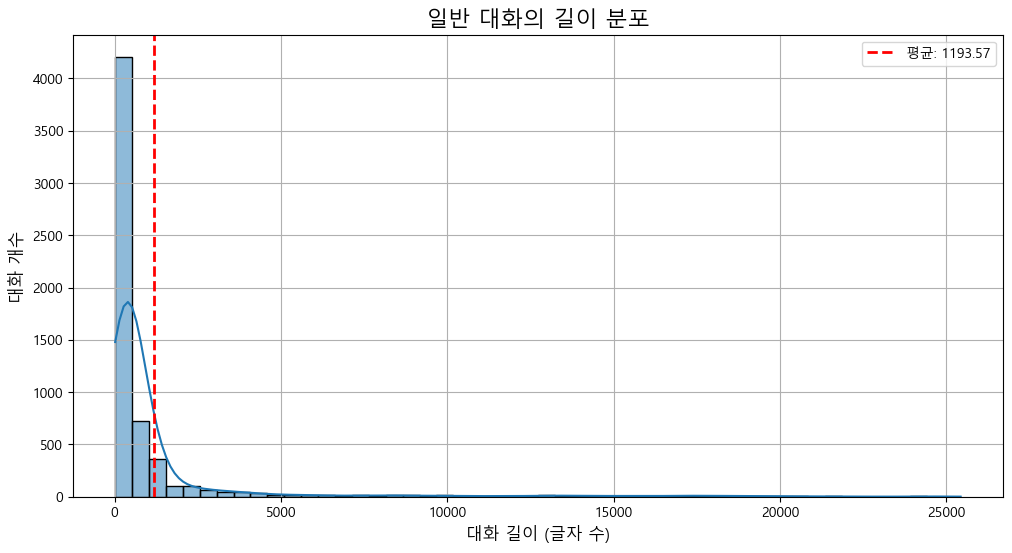

In [6]:
# 파일명: eda_normal_data.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Windows에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# --- 1. 데이터 로드 ---
input_file = "normal_컬럼정리.csv"
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 행)")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    sys.exit()

# --- 2. 파일 아이디(file_id)별로 텍스트 합치기 ---
# 'file_id'로 그룹을 묶고, 각 그룹의 'text' 컬럼을 공백으로 이어붙임
print("파일 아이디를 기준으로 텍스트를 합치는 중...")
aggregated_df = df.groupby("file_id").agg(full_text=("text", " ".join)).reset_index()
print("텍스트 합치기 완료!")

# --- 3. 합쳐진 텍스트의 길이 계산 ---
aggregated_df["text_length"] = aggregated_df["full_text"].str.len()

# --- 4. 핵심 지표 계산 및 출력 ---
# 전체 대화(파일) 개수
total_conversations = len(aggregated_df)
# 평균 대화 길이
mean_length = aggregated_df["text_length"].mean()
# 최소/최대 길이
min_length = aggregated_df["text_length"].min()
max_length = aggregated_df["text_length"].max()

print("\n--- 일반 대화 데이터 EDA 결과 ---")
print(f"분석된 총 대화(파일) 개수: {total_conversations}개")
print(f"평균 대화 길이: {mean_length:.2f}자")
print(f"가장 짧은 대화 길이: {min_length}자")
print(f"가장 긴 대화 길이: {max_length}자")
print("---------------------------------")


# --- 5. 대화 길이 분포 시각화 (히스토그램) ---
plt.figure(figsize=(12, 6))
sns.histplot(aggregated_df["text_length"], bins=50, kde=True)
# 평균값 위치에 수직선 추가
plt.axvline(
    mean_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"평균: {mean_length:.2f}",
)
plt.title("일반 대화의 길이 분포", fontsize=16)
plt.xlabel("대화 길이 (글자 수)", fontsize=12)
plt.ylabel("대화 개수", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

'phishing_total_컬럼정리.csv' 파일 로드 완료! (총 203299개 행)
파일 아이디를 기준으로 텍스트를 합치는 중...
텍스트 합치기 완료!

--- 일반 대화 데이터 EDA 결과 ---
분석된 총 대화(파일) 개수: 6386개
평균 대화 길이: 1188.74자
가장 짧은 대화 길이: 19자
가장 긴 대화 길이: 48345자
---------------------------------


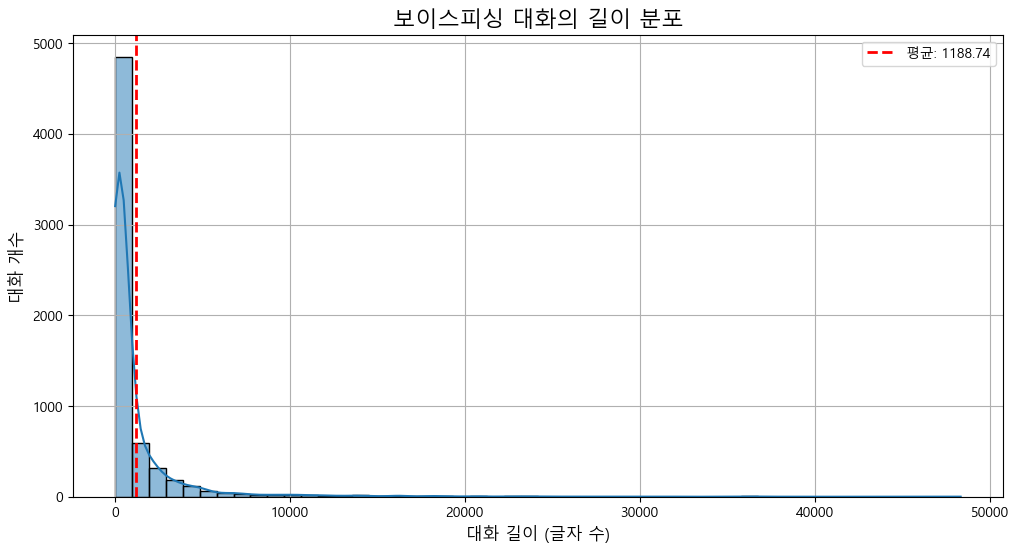

In [8]:
# 파일명: eda_normal_data.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Windows에서 한글 폰트가 깨지지 않도록 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# --- 1. 데이터 로드 ---
input_file = "phishing_total_컬럼정리.csv"
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 행)")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    sys.exit()

# --- 2. 파일 아이디(file_id)별로 텍스트 합치기 ---
# 'file_id'로 그룹을 묶고, 각 그룹의 'text' 컬럼을 공백으로 이어붙임
print("파일 아이디를 기준으로 텍스트를 합치는 중...")
aggregated_df = df.groupby("file_id").agg(full_text=("text", " ".join)).reset_index()
print("텍스트 합치기 완료!")

# --- 3. 합쳐진 텍스트의 길이 계산 ---
aggregated_df["text_length"] = aggregated_df["full_text"].str.len()

# --- 4. 핵심 지표 계산 및 출력 ---
# 전체 대화(파일) 개수
total_conversations = len(aggregated_df)
# 평균 대화 길이
mean_length = aggregated_df["text_length"].mean()
# 최소/최대 길이
min_length = aggregated_df["text_length"].min()
max_length = aggregated_df["text_length"].max()

print("\n--- 일반 대화 데이터 EDA 결과 ---")
print(f"분석된 총 대화(파일) 개수: {total_conversations}개")
print(f"평균 대화 길이: {mean_length:.2f}자")
print(f"가장 짧은 대화 길이: {min_length}자")
print(f"가장 긴 대화 길이: {max_length}자")
print("---------------------------------")


# --- 5. 대화 길이 분포 시각화 (히스토그램) ---
plt.figure(figsize=(12, 6))
sns.histplot(aggregated_df["text_length"], bins=50, kde=True)
# 평균값 위치에 수직선 추가
plt.axvline(
    mean_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"평균: {mean_length:.2f}",
)
plt.title("보이스피싱 대화의 길이 분포", fontsize=16)
plt.xlabel("대화 길이 (글자 수)", fontsize=12)
plt.ylabel("대화 개수", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
import sys

# --- 1. 파일 경로 설정 ---
normal_talk_file = "normal_컬럼정리.csv"
phishing_talk_file = "phishing_total_컬럼정리.csv"
output_file = "voicephishing_original_data.csv"

# --- 2. 데이터 로드 ---
try:
    normal_df = pd.read_csv(normal_talk_file)
    phishing_df = pd.read_csv(phishing_talk_file)
    print("일반 대화, 보이스피싱 대화 파일 로드 완료!")
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다. -> {e}")
    sys.exit()


# --- 3. 파일별(file_id)로 텍스트 합치기 ---
# groupby('file_id')을 사용해서 동일한 파일명을 가진 행들을 그룹으로 묶음
# agg() 함수로 각 그룹에 대한 집계 작업을 수행
def aggregate_text(df):
    # 'text' 컬럼은 공백으로 이어붙이고,
    # 'is_phishing' 컬럼은 그룹 내 첫 번째 값을 사용 (어차피 다 같으므로)
    agg_df = (
        df.groupby("file_id")
        .agg(text=("text", " ".join), is_phishing=("is_phishing", "first"))
        .reset_index()
    )  # 그룹화된 결과를 다시 데이터프레임으로 변환
    return agg_df


print("파일별로 텍스트를 합치는 중...")
normal_agg_df = aggregate_text(normal_df)
phishing_agg_df = aggregate_text(phishing_df)
print("텍스트 합치기 완료!")

# --- 4. 합쳐진 데이터프레임들을 다시 하나로 결합 ---
total_df = pd.concat([normal_agg_df, phishing_agg_df], ignore_index=True)

# --- 5. 데이터 섞기 (이제 행 단위로 섞어도 파일 단위로 섞는 것과 같음) ---
total_df = total_df.sample(frac=1).reset_index(drop=True)
print("최종 데이터 합치기 및 섞기 완료!")

# --- 6. 최종 파일로 저장 ---
total_df.to_csv(output_file, index=False, encoding="utf-8-sig")
print(
    f"'{output_file}' 파일 저장 완료! 총 {len(total_df)}개의 '대화' 데이터가 저장되었습니다."
)

일반 대화, 보이스피싱 대화 파일 로드 완료!
파일별로 텍스트를 합치는 중...
텍스트 합치기 완료!
최종 데이터 합치기 및 섞기 완료!
'voicephishing_original_data.csv' 파일 저장 완료! 총 12386개의 '대화' 데이터가 저장되었습니다.


# 일반대화와 길이 맞추고 현재 유형분포도와 흡사하게 6000개의 파일만 추리기

In [15]:
# 파일명: final_sampler_v3.py (6000개 보장 최종본)

import pandas as pd
import numpy as np
import sys

# --- Part 1 & 2: 이전과 동일 (데이터 로드, 집계, 기준점 설정) ---
try:
    normal_raw_df = pd.read_csv("normal_컬럼정리.csv")
    phishing_raw_df = pd.read_csv("phishing_total_컬럼정리.csv")
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다 -> {e}")
    sys.exit()

normal_raw_df["phishing_type"] = "일반"


def aggregate_by_file_id(df):
    return (
        df.groupby("file_id")
        .agg(
            text=("text", " ".join),
            phishing_type=("phishing_type", "first"),
            is_phishing=("is_phishing", "first"),
        )
        .reset_index()
    )


normal_df = aggregate_by_file_id(normal_raw_df)
phishing_df = aggregate_by_file_id(phishing_raw_df)

mean_normal_length = normal_df["text"].str.len().mean()


# --- Part 3: 목표 개수 지능형 재조정 (새로운 로직) ---
print("\n--- [목표 재조정 시작] ---")
# 3-1. 초기 목표치 계산
target_ratios = {
    "기관사칭형": 0.53,
    "대출빙자형": 0.225,
    "메신저피싱형": 0.08,
    "택배사칭형": 0.07,
    "가족지인사칭형": 0.06,
    "콜백스미싱형": 0.04,
    "투자권유형": 0.03,
}
total_ratio = sum(target_ratios.values())
normalized_ratios = {k: v / total_ratio for k, v in target_ratios.items()}
initial_target_counts = {k: round(v * 6000) for k, v in normalized_ratios.items()}
# (이전과 동일)

# 3-2. 실제 보유량과 비교하여 부족분 계산
actual_counts = phishing_df["phishing_type"].value_counts().to_dict()
adjusted_target_counts = {}
shortfall = 0

for phish_type, target_count in initial_target_counts.items():
    actual_count = actual_counts.get(phish_type, 0)
    if actual_count < target_count:
        # 보유량이 목표치보다 적으면, 보유량만큼만 가져오도록 목표 수정
        adjusted_target_counts[phish_type] = actual_count
        shortfall += target_count - actual_count
        print(f"'{phish_type}' 유형 부족분 발생: {target_count - actual_count}개")
    else:
        # 충분하면 일단 초기 목표치 유지
        adjusted_target_counts[phish_type] = target_count

print(f"총 부족분: {shortfall}개")

# 3-3. 부족분을 데이터가 풍부한 유형에 비례하여 재배분
if shortfall > 0:
    # 데이터가 풍부한 유형들만 필터링
    abundant_types = {
        k: v for k, v in initial_target_counts.items() if actual_counts.get(k, 0) >= v
    }

    # 풍부한 유형들의 원래 목표치 총합 계산
    total_abundant_target = sum(abundant_types.values())

    print(f"{shortfall}개의 부족분을 데이터가 풍부한 유형들에 비례하여 재배분합니다...")
    # 비례하여 부족분 나누기
    for phish_type, target_count in abundant_types.items():
        reallocation_share = round((target_count / total_abundant_target) * shortfall)
        adjusted_target_counts[phish_type] += reallocation_share

# 3-4. 최종 합계 6000개 보정
final_diff = 6000 - sum(adjusted_target_counts.values())
if final_diff != 0:
    # 가장 많은 유형의 키를 찾아서 최종 오차 보정
    max_type = max(adjusted_target_counts, key=adjusted_target_counts.get)
    adjusted_target_counts[max_type] += final_diff

print("\n[최종 샘플링 계획]")
print(pd.Series(adjusted_target_counts))


# --- Part 4, 5, 6: 이전과 동일 (점수 계산, 샘플링, 저장) ---
phishing_df["text_length"] = phishing_df["text"].str.len()
phishing_df["length_score"] = np.abs(phishing_df["text_length"] - mean_normal_length)

final_phishing_list = []
# [중요] 이제는 `adjusted_target_counts`를 사용
for phish_type, count in adjusted_target_counts.items():
    type_subset = phishing_df[phishing_df["phishing_type"] == phish_type]
    sampled_subset = type_subset.sort_values(by="length_score").head(count)
    final_phishing_list.append(sampled_subset)

final_phishing_df = pd.concat(final_phishing_list)

final_phishing_df_to_save = final_phishing_df.drop(
    columns=["text_length", "length_score"]
)
output_file = "phishing_sampled_final_6000_exact.csv"
final_phishing_df_to_save.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\n--- 최종 결과 ---")
print(
    f"최종 정제된 {len(final_phishing_df_to_save)}개의 보이스피싱 데이터를 '{output_file}'로 저장했습니다."
)
print("최종 유형별 분포:")
print(final_phishing_df_to_save["phishing_type"].value_counts(normalize=True).round(3))


--- [목표 재조정 시작] ---
'메신저피싱형' 유형 부족분 발생: 44개
'택배사칭형' 유형 부족분 발생: 46개
'가족지인사칭형' 유형 부족분 발생: 47개
'콜백스미싱형' 유형 부족분 발생: 53개
'투자권유형' 유형 부족분 발생: 54개
총 부족분: 244개
244개의 부족분을 데이터가 풍부한 유형들에 비례하여 재배분합니다...

[최종 샘플링 계획]
기관사칭형      3243
대출빙자형      1377
메신저피싱형      420
택배사칭형       360
가족지인사칭형     301
콜백스미싱형      179
투자권유형       120
dtype: int64

--- 최종 결과 ---
최종 정제된 6000개의 보이스피싱 데이터를 'phishing_sampled_final_6000_exact.csv'로 저장했습니다.
최종 유형별 분포:
phishing_type
기관사칭형      0.54
대출빙자형      0.23
메신저피싱형     0.07
택배사칭형      0.06
가족지인사칭형    0.05
콜백스미싱형     0.03
투자권유형      0.02
Name: proportion, dtype: float64


# 일반대화데이터 피싱대화와 컬럼 통일 및 파일아이디같은 행 합치기

In [16]:
import pandas as pd
import sys

# --- 1. 데이터 로드 ---
input_file = "normal_컬럼정리.csv"
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 행)")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다.")
    sys.exit()

# --- 2. 'phishing_type' 컬럼 생성 및 공백으로 채우기 ---
# 네 요청대로, phishing_type 컬럼을 만들고 빈 문자열('')로 채움
df["phishing_type"] = ""
print("'phishing_type' 컬럼을 생성하고 공백으로 채웠습니다.")


# --- 3. 'file_id'를 기준으로 그룹화 및 텍스트 병합 ---
print("file_id를 기준으로 텍스트를 합치는 중...")
aggregated_df = (
    df.groupby("file_id")
    .agg(
        text=("text", " ".join),  # 텍스트는 공백으로 이어붙이기
        phishing_type=("phishing_type", "first"),  # 어차피 다 공백이므로 첫번째 값 사용
        is_phishing=("is_phishing", "first"),  # 어차피 다 0이므로 첫번째 값 사용
    )
    .reset_index()
)
print(f"-> {len(aggregated_df)}개의 대화(파일)로 재구성 완료.")


# --- 4. 최종 컬럼 순서 정리 ---
# 네가 요청한 순서대로 컬럼을 재배열
final_df = aggregated_df[["file_id", "text", "phishing_type", "is_phishing"]]
print("컬럼 순서를 'file_id', 'text', 'phishing_type', 'is_phishing'로 정리했습니다.")


# --- 5. 결과 저장 ---
output_file = "normal_final.csv"
final_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\n모든 작업 완료! 최종 일반 대화 데이터를 '{output_file}'로 저장했습니다.")

'normal_컬럼정리.csv' 파일 로드 완료! (총 194240개 행)
'phishing_type' 컬럼을 생성하고 공백으로 채웠습니다.
file_id를 기준으로 텍스트를 합치는 중...
-> 6000개의 대화(파일)로 재구성 완료.
컬럼 순서를 'file_id', 'text', 'phishing_type', 'is_phishing'로 정리했습니다.

모든 작업 완료! 최종 일반 대화 데이터를 'normal_final.csv'로 저장했습니다.


# 데이터 중복확인됨 기관사칭형 독일어 다시합쳐야함!! 우선 순차 진행해보기!

# 데이터 랜덤으로 저장한 마스터셋 파일

In [26]:
# 파일명: 1_create_master_dataset_no_dedup.py

import pandas as pd
import sys

# --- 1. 최종 준비된 두 데이터 파일 로드 ---
try:
    normal_final_df = pd.read_csv("normal_final.csv")
    phishing_final_df = pd.read_csv("phishing_final.csv")
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다 -> {e}")
    sys.exit()

# --- 2. 두 데이터프레임 하나로 합치기 ---
master_df = pd.concat([normal_final_df, phishing_final_df], ignore_index=True)
print(f"두 데이터셋 결합 완료. 총 데이터 개수: {len(master_df)}개")

# --- 3. 최종 데이터셋 무작위로 섞기 ---
master_df = master_df.sample(frac=1).reset_index(drop=True)
print("최종 데이터셋 무작위 섞기 완료.")

# --- 4. 마스터 데이터셋 저장 ---
output_file = "master_dataset_final.csv"
master_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\n모든 작업 완료! 최종 마스터 데이터셋을 '{output_file}'로 저장했습니다.")

두 데이터셋 결합 완료. 총 데이터 개수: 12000개
최종 데이터셋 무작위 섞기 완료.

모든 작업 완료! 최종 마스터 데이터셋을 'master_dataset_final.csv'로 저장했습니다.


# 토큰화 저장

In [1]:
# 파일명: 2_tokenize_master_dataset.py

import pandas as pd
from kiwipiepy import Kiwi
import sys

# --- 1. 마스터 데이터셋 로드 ---
input_file = "master_dataset_final.csv"
output_file = "master_dataset_with_tokens_final.csv"
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 대화)")
except FileNotFoundError:
    print(f"에러: '{input_file}' 파일을 찾을 수 없습니다. Step 1을 먼저 실행해주세요.")
    sys.exit()

# --- 2. Kiwi 형태소 분석기 정의 ---
kiwi = Kiwi()


def kiwi_tokenizer(text):
    stopwords = ["하다", "있다", "되다", "없다", "아", "그", "저"]
    if not isinstance(text, str):
        return []
    result = kiwi.analyze(text)
    tokens = [
        token.lemma
        for token in result[0][0]
        if token.tag in ["NNG", "NNP", "VV", "VA"] and token.lemma not in stopwords
    ]
    return tokens


# --- 3. 토큰화 실행 및 'tokens' 컬럼 생성 ---
print("마스터 데이터셋 전체 토큰화를 시작합니다... (시간이 소요됩니다)")
df["tokens"] = df["text"].apply(kiwi_tokenizer)
print("토큰화 작업 완료!")

# --- 4. 최종 토큰화 파일 저장 ---
df.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"토큰화된 최종 데이터 파일을 '{output_file}'로 저장했습니다.")

'master_dataset_final.csv' 파일 로드 완료! (총 12000개 대화)
마스터 데이터셋 전체 토큰화를 시작합니다... (시간이 소요됩니다)
토큰화 작업 완료!
토큰화된 최종 데이터 파일을 'master_dataset_with_tokens_final.csv'로 저장했습니다.


# 벡터화 파일저장

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import sys
import ast  # CSV에 문자열로 저장된 리스트를 실제 리스트로 변환하기 위해 필요
import joblib  # 모델과 벡터를 저장하기 위해 사용

# --- 1. 토큰화된 데이터 로드 ---
input_file = "master_dataset_with_tokens_final.csv"
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 대화)")
except FileNotFoundError:
    print(
        f"에러: '{input_file}' 파일을 찾을 수 없습니다. 이전 단계를 먼저 실행해주세요."
    )
    sys.exit()

# --- 2. 토큰 리스트 전처리 ---
# CSV에 저장되면서 'tokens' 컬럼은 문자열 형태("['단어1', '단어2']")가 됩니다.
# ast.literal_eval을 사용해 문자열을 실제 파이썬 리스트로 변환합니다.
# TfidfVectorizer는 ['단어1', '단어2'] 형태가 아닌 '단어1 단어2' 형태의 문자열을 입력으로 받습니다.
try:
    print("토큰 리스트를 TfidfVectorizer 입력 형식(문자열)으로 변환합니다...")
    # 1. 문자열 -> 리스트 변환
    df["tokens_list"] = df["tokens"].apply(ast.literal_eval)
    # 2. 토큰 리스트 -> 공백으로 구분된 문자열 변환
    df["tokens_str"] = df["tokens_list"].apply(lambda tokens: " ".join(tokens))
    print("변환 완료!")

except (ValueError, SyntaxError):
    print("에러: 'tokens' 컬럼을 파싱하는 데 문제가 발생했습니다.")
    print("데이터가 ['토큰1', '토큰2'] 형식의 문자열이 맞는지 확인해주세요.")
    sys.exit()


# --- 3. TfidfVectorizer로 벡터화 ---
print("TfidfVectorizer를 사용하여 벡터화를 시작합니다... (ngram_range=(1, 2))")

# TfidfVectorizer 객체 생성
# ngram_range=(1, 2): 단어(1-gram)와 연속된 두 단어(2-gram)를 모두 고려
# min_df=2: 최소 2개 이상의 문서(대화)에 나타난 단어만 피처로 사용 (희소 단어 제거)
# max_df=0.95: 너무 많은 문서(95% 이상)에 나타난 단어는 피처에서 제외 (너무 흔한 단어 제거)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)

# fit_transform()으로 TF-IDF 행렬 생성
tfidf_matrix = tfidf_vectorizer.fit_transform(df["tokens_str"])

print("벡터화 작업 완료!")
print(f"생성된 TF-IDF 행렬의 크기: {tfidf_matrix.shape}")
print(f"(문서 수: {tfidf_matrix.shape[0]}, 피처(n-gram) 수: {tfidf_matrix.shape[1]})")

# 생성된 피처(n-gram) 샘플 확인
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\\n--- 감지된 피처 (n-grams) 샘플 ---")
print("첫 20개:", feature_names[:20])
print("마지막 20개:", feature_names[-20:])
print("-" * 30)


# --- 4. 결과물 저장 ---
# 생성된 TF-IDF 행렬과 Vectorizer 객체를 파일로 저장하여 다음 단계에서 활용합니다.
vectorizer_output_file = "tfidf_vectorizer.joblib"
matrix_output_file = "tfidf_matrix.joblib"

joblib.dump(tfidf_vectorizer, vectorizer_output_file)
joblib.dump(tfidf_matrix, matrix_output_file)

print(f"TfidfVectorizer 객체를 '{vectorizer_output_file}' 파일로 저장했습니다.")
print(f"TF-IDF 행렬을 '{matrix_output_file}' 파일로 저장했습니다.")
print(
    "\\n이제 이 행렬을 사용하여 군집화(Clustering)나 분류(Classification) 모델링을 진행할 수 있습니다."
)

'master_dataset_with_tokens_final.csv' 파일 로드 완료! (총 12000개 대화)
토큰 리스트를 TfidfVectorizer 입력 형식(문자열)으로 변환합니다...
변환 완료!
TfidfVectorizer를 사용하여 벡터화를 시작합니다... (ngram_range=(1, 2))
벡터화 작업 완료!
생성된 TF-IDF 행렬의 크기: (12000, 121867)
(문서 수: 12000, 피처(n-gram) 수: 121867)
\n--- 감지된 피처 (n-grams) 샘플 ---
첫 20개: ['11번가' '11번가 마켓' '11번가 사이트' '11번가 옥션' '11번가 지마켓' 'cj대한통운' 'cj대한통운 고객'
 'cj대한통운 안녕' 'f1' 'f2' 'kb국민은행' 'kb국민은행 상환' 'nh농협' 'nh농협 상대' 'nh농협 중앙'
 'nh농협은행' 'nh농협은행 고객' 'nh농협은행 대출' 'nh농협은행 신용' 'nh농협은행 지점']
마지막 20개: ['힘들다 통화' '힘들다 평소' '힘들다 포기' '힘들다 프로젝트' '힘들다 피곤' '힘들다 필요' '힘들다 하루' '힘들다 학교'
 '힘들다 학생' '힘들다 해결' '힘들다 혼자' '힘들다 확인' '힘들다 회사' '힘들다 회원' '힘들다 훔치다' '힘들다 힘들다'
 '힘들어지다' '힘들어지다 같다' '힘쓰다' '힘차다']
------------------------------
TfidfVectorizer 객체를 'tfidf_vectorizer.joblib' 파일로 저장했습니다.
TF-IDF 행렬을 'tfidf_matrix.joblib' 파일로 저장했습니다.
\n이제 이 행렬을 사용하여 군집화(Clustering)나 분류(Classification) 모델링을 진행할 수 있습니다.


In [10]:
import pandas as pd
import ast
import sys
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. 데이터 로드 및 전처리 ---
input_file = "master_dataset_with_tokens_final.csv"
df = pd.read_csv(input_file)
df["tokens_list"] = df["tokens"].apply(ast.literal_eval)
df["tokens_str"] = df["tokens_list"].apply(lambda tokens: " ".join(tokens))
print("데이터 로드 및 전처리 완료.")

# --- 2. 훈련/검증 데이터 분리 ---
X = df["tokens_str"]
y = df["is_phishing"]  # 'label' 대신 실제 컬럼명('분류')으로 수정
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("데이터 분리 완료.")

# --- 3. TF-IDF 벡터화 ---
print("TF-IDF 벡터화 시작...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("벡터화 완료.")

# --- 4. 특징 선택 (SelectKBest) ---
print("SelectKBest 특징 선택 시작...")
selector = SelectKBest(score_func=chi2, k=2000)
# 'selector' 객체를 사용해서 변환된 결과를 'X_train_kbest'에 저장합니다. (덮어쓰지 않음)
X_train_kbest = selector.fit_transform(X_train_tfidf, y_train)
X_test_kbest = selector.transform(X_test_tfidf)
print("특징 선택 완료.")

# --- 5. LightGBM 모델 훈련 ---
print("LGBM 모델 훈련 시작...")
lgbm_model = LGBMClassifier(n_estimators=400, random_state=42)
lgbm_model.fit(X_train_kbest, y_train)
print("모델 훈련 완료.")

# --- 6. 모델 평가 ---
y_pred = lgbm_model.predict(X_test_kbest)
print("\n--- 모델 성능 평가 ---")
print(f"정확도: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# --- 7. 학습된 객체들을 올바르게 저장 (가장 중요) ---
print("\n--- 학습된 객체 저장 시작 ---")
# 도구(객체) 자체를 저장합니다.
joblib.dump(vectorizer, "tfidf_vectorizer_trained.joblib")
joblib.dump(selector, "kbest_selector.joblib")
joblib.dump(lgbm_model, "lgbm_model.joblib")
print(
    "저장 완료: 'tfidf_vectorizer_trained.joblib', 'kbest_selector.joblib', 'lgbm_model.joblib'"
)

데이터 로드 및 전처리 완료.
데이터 분리 완료.
TF-IDF 벡터화 시작...
벡터화 완료.
SelectKBest 특징 선택 시작...
특징 선택 완료.
LGBM 모델 훈련 시작...
[LightGBM] [Info] Number of positive: 4800, number of negative: 4800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 112416
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 1952
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

c:\Users\user\Downloads\woogawooga\woogawooga_project\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


저장 완료: 'tfidf_vectorizer_trained.joblib', 'kbest_selector.joblib', 'lgbm_model.joblib'


In [7]:
import pandas as pd
import ast
import sys
import joblib  # 저장된 객체를 불러오기 위해 필요

# --- Scikit-learn 및 LightGBM 라이브러리 ---
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 필요한 파일 이름 정의 ---
input_file = "master_dataset_with_tokens_final.csv"
vectorizer_path = "tfidf_vectorizer.joblib"
selector_path = "tfidf_matrix.joblib"
new_model_path = "lgbm_model_retrained.joblib"  # 새로 훈련된 모델 저장 경로

# --- 1. 데이터 로드 및 전처리 (이전과 동일) ---
try:
    df = pd.read_csv(input_file)
    print(f"'{input_file}' 파일 로드 완료! (총 {len(df)}개 대화)")
except FileNotFoundError:
    print(
        f"에러: '{input_file}' 파일을 찾을 수 없습니다. 이전 단계를 먼저 실행해주세요."
    )
    sys.exit()

# 'tokens' 컬럼을 TfidfVectorizer 입력 형식으로 변환
try:
    df["tokens_list"] = df["tokens"].apply(ast.literal_eval)
    df["tokens_str"] = df["tokens_list"].apply(lambda tokens: " ".join(tokens))
    print("토큰 데이터 전처리 완료!")
except Exception as e:
    print(f"에러: 'tokens' 컬럼 파싱 중 문제 발생: {e}")
    sys.exit()

# --- 2. 훈련/검증 데이터 분리 (이전과 동일) ---
X = df["tokens_str"]
y = df["is_phishing"]  # 실제 타겟 컬럼명 확인 필요
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"데이터 분리 완료: 훈련 데이터 {len(X_train)}개, 검증 데이터 {len(X_test)}개")


# --- 3. 저장된 Vectorizer 및 Selector 로드 (핵심 변경 사항) ---
try:
    print("\n--- 저장된 Vectorizer와 Selector 로드 시작 ---")
    vectorizer = joblib.load(vectorizer_path)
    selector = joblib.load(selector_path)
    print(f"'{vectorizer_path}'와 '{selector_path}' 로드 완료!")
except FileNotFoundError:
    print(f"에러: '{vectorizer_path}' 또는 '{selector_path}' 파일을 찾을 수 없습니다.")
    print("먼저 모델 훈련 코드를 실행하여 해당 파일들을 생성해야 합니다.")
    sys.exit()

# --- 4. 로드된 객체로 데이터 변환 (fit 과정 생략) ---
print("\n--- 로드된 객체로 데이터 변환 시작 (transform만 사용) ---")
# .fit_transform() 대신 .transform()을 사용하여 기존 규칙을 그대로 적용합니다.
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("TF-IDF 변환 완료!")

X_train_kbest = selector.transform(X_train_tfidf)
X_test_kbest = selector.transform(X_test_tfidf)
print(f"특징 선택 완료! 선택된 피처 수: {X_train_kbest.shape[1]}")


# --- 5. LightGBM 모델 훈련 (이전과 동일) ---
print("\n--- LGBMClassifier 모델 훈련 시작 ---")
lgbm_model = LGBMClassifier(n_estimators=400, random_state=42)
lgbm_model.fit(X_train_kbest, y_train)
print("모델 훈련 완료!")

# --- 6. 모델 평가 (이전과 동일) ---
print("\n--- 모델 성능 평가 ---")
y_pred = lgbm_model.predict(X_test_kbest)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도(Accuracy): {accuracy:.4f}")
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))

# --- 7. 새로 훈련된 모델만 저장 ---
print("\n--- 새롭게 훈련된 모델 저장 ---")
joblib.dump(lgbm_model, new_model_path)
print(f"저장 완료: '{new_model_path}'")

'master_dataset_with_tokens_final.csv' 파일 로드 완료! (총 12000개 대화)
토큰 데이터 전처리 완료!
데이터 분리 완료: 훈련 데이터 9600개, 검증 데이터 2400개

--- 저장된 Vectorizer와 Selector 로드 시작 ---
'tfidf_vectorizer.joblib'와 'tfidf_matrix.joblib' 로드 완료!

--- 로드된 객체로 데이터 변환 시작 (transform만 사용) ---
TF-IDF 변환 완료!


AttributeError: 'csr_matrix' object has no attribute 'transform'

# 중복 찾는 작업

In [4]:
# 데이터 분석 필수 라이브러리인 '판다스(pandas)'를 불러오는 코드야.
import pandas as pd

# 처리할 파일 이름을 변수에 저장해.
# 만약 다른 폴더에 있다면 'C:/Users/..../phishing_final.csv' 처럼 전체 경로를 적어줘야 해.
file_name = "phishing_merged_by_id.csv"

try:
    # 판다스를 이용해 CSV 파일을 읽어와서 df라는 변수에 저장해.
    df = pd.read_csv(file_name)

    print("--- 작업 시작 ---")
    print(f"중복 제거 전 원본 데이터 행 개수: {len(df)}")

    # 'text' 컬럼을 기준으로 중복된 행을 제거하는 핵심 코드야.
    # subset=['text'] : 어떤 컬럼의 중복을 확인할지 정해주는 부분이야.
    # keep='first' : 중복된 데이터 중 첫 번째 데이터는 남기고 나머지를 삭제하라는 의미지.
    df_cleaned = df.drop_duplicates(subset=["text"], keep="first")

    print(f"중복 제거 후 데이터 행 개수: {len(df_cleaned)}")
    print("-----------------")

    removed_count = len(df) - len(df_cleaned)
    print(f"\n총 {removed_count}개의 중복된 행을 삭제했어!")

    # [선택 사항]
    # 만약 중복이 제거된 깨끗한 데이터를 새로운 파일로 저장하고 싶다면,
    # 아래 코드 앞의 #을 지우고 실행해.
    output_filename = 'phishing_final_cleaned.csv'
    df_cleaned.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"'{output_filename}' 이름으로 깨끗한 데이터가 저장됐어.")


except FileNotFoundError:
    # 파일이 없거나 이름이 틀렸을 때 알려주는 부분이야.
    print(f"'{file_name}' 파일을 찾을 수 없어. 파일 이름이나 경로를 다시 확인해 봐.")

except Exception as e:
    # 그 외 다른 오류가 발생했을 때 알려주는 부분이야.
    print(f"이런! 오류가 발생했네: {e}")

--- 작업 시작 ---
중복 제거 전 원본 데이터 행 개수: 6386
중복 제거 후 데이터 행 개수: 5532
-----------------

총 854개의 중복된 행을 삭제했어!
'phishing_final_cleaned.csv' 이름으로 깨끗한 데이터가 저장됐어.


In [6]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 처리할 파일의 이름을 변수에 저장합니다.
# 다른 폴더에 있다면 전체 경로를 정확하게 입력해야 합니다.
file_name = "기관사칭_독일어.csv"

try:
    # CSV 파일을 읽어와 데이터프레임(df)으로 만듭니다.
    df = pd.read_csv(file_name)

    print("--- 원본 데이터 샘플 (상위 5개) ---")
    print(df.head())
    print("\n--- 작업 시작 ---")

    # 'file_id'를 기준으로 데이터를 그룹화하고, 각 그룹별로 집계 작업을 수행합니다.
    df_merged = (
        df.groupby("file_id")
        .agg(
            # phishing_type 컬럼은 그룹 내 첫 번째 값을 사용합니다.
            phishing_type=("phishing_type", "first"),
            # speaker 컬럼도 그룹 내 첫 번째 값을 사용합니다.
            speaker=("speaker", "first"),
            # text 컬럼은 그룹 내 모든 텍스트를 공백(' ')을 사이에 두고 순서대로 합칩니다.
            text=("text", " ".join),
        )
        .reset_index()
    )  # 그룹화의 기준이었던 'file_id'를 다시 일반 컬럼으로 변경합니다.

    # 사용자가 요청한 컬럼 순서대로 재정렬합니다.
    final_columns = ["file_id", "phishing_type", "speaker", "text"]
    df_final = df_merged[final_columns]

    print("\n--- 텍스트 병합 완료된 데이터 샘플 (상위 5개) ---")
    print(df_final.head())

    # [선택 사항]
    # 병합된 결과를 새로운 CSV 파일로 저장하고 싶다면, 아래 코드 앞의 '#'을 지우고 실행하세요.
    output_filename = '기관사칭_독일어_merged.csv'
    df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"\n'{output_filename}' 이름으로 병합된 파일이 저장되었습니다.")


except FileNotFoundError:
    # 파일을 찾지 못했을 경우 오류 메시지를 출력합니다.
    print(
        f"오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름이나 경로를 다시 확인해주세요."
    )
except KeyError as e:
    # 파일에 필요한 컬럼이 없을 경우 오류 메시지를 출력합니다.
    print(
        f"오류: CSV 파일에 필요한 컬럼이 없습니다 - {e}. 컬럼 이름을 확인해주세요: 'file_id', 'phishing_type', 'speaker', 'text'"
    )
except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 원본 데이터 샘플 (상위 5개) ---
                           file_id phishing_type  speaker  \
0  phishing_1930_en_de_augmented_1         기관사칭형        0   
1  phishing_1930_en_de_augmented_1         기관사칭형        1   
2  phishing_1024_en_de_augmented_2         기관사칭형        1   
3  phishing_1024_en_de_augmented_2         기관사칭형        0   
4  phishing_1024_en_de_augmented_2         기관사칭형        1   

                                                text  
0  네, 안녕하세요. 저는 서울지방경찰청 경제범죄수사과의 김범석입니다. 합천에 계신 분...  
1  2월 18일부터 20일까지 9일 동안 약 4,500만 원이 불법 자금 세탁에 사용된...  
2                                  네, 무슨 일로 전화 주셨나요?  
3  최근 건강보험 정보가 유출되어 확인이 필요합니다. 정보를 조금 업데이트해 주셔야 할...  
4                              어떤 정보가 유출되었다는 말씀이신가요?  

--- 작업 시작 ---

--- 텍스트 병합 완료된 데이터 샘플 (상위 5개) ---
                             file_id phishing_type  speaker  \
0  phishing_1000_en_de_augmented_337         기관사칭형        0   
1   phishing_1001_en_de_augmented_83         기관사칭형        0   
2  phishing_1002_en_de_augmented_192  

In [7]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 합치고 싶은 파일들의 이름을 각각 변수에 저장합니다.
# 이전에 우리가 만들기로 했던 파일 이름이야.
file1_name = "phishing_final_cleaned.csv"
file2_name = "기관사칭_독일어_merged.csv"

try:
    # 두 개의 CSV 파일을 각각 읽어와 데이터프레임으로 만듭니다.
    df1 = pd.read_csv(file1_name)
    df2 = pd.read_csv(file2_name)

    print(f"--- 파일 정보 ---")
    print(f"첫 번째 파일 '{file1_name}' 행 개수: {len(df1)}")
    print(f"두 번째 파일 '{file2_name}' 행 개수: {len(df2)}")

    # pd.concat을 사용하여 두 데이터프레임을 세로로(아래로) 합칩니다.
    # ignore_index=True는 기존의 인덱스(행 번호)를 무시하고, 0부터 새로 번호를 매기라는 의미입니다.
    # 두 파일의 컬럼(열) 이름이 달라도 괜찮아. 없는 컬럼은 빈 값(NaN)으로 채워지면서 합쳐져.
    combined_df = pd.concat([df1, df2], ignore_index=True)

    print("\n--- 통합 완료 ---")
    print(f"최종적으로 합쳐진 데이터의 총 행 개수: {len(combined_df)}")

    # [선택 사항]
    # 최종적으로 합쳐진 데이터를 새로운 CSV 파일로 저장하고 싶다면,
    # 아래 코드 앞의 '#'을 지우고 실행하세요.
    output_filename = 'total_phishing_data.csv'
    combined_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
    print(f"\n'{output_filename}' 이름으로 통합된 최종 파일이 저장되었습니다.")


except FileNotFoundError as e:
    # 두 파일 중 하나라도 없으면 오류 메시지를 출력합니다.
    print(
        f"오류: 파일을 찾을 수 없습니다. '{e.filename}' 파일이 현재 폴더에 있는지 확인해주세요."
    )
    print("이전 단계에서 파일이 정상적으로 저장되었는지 먼저 확인해봐!")
except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 파일 정보 ---
첫 번째 파일 'phishing_final_cleaned.csv' 행 개수: 5532
두 번째 파일 '기관사칭_독일어_merged.csv' 행 개수: 500

--- 통합 완료 ---
최종적으로 합쳐진 데이터의 총 행 개수: 6032

'total_phishing_data.csv' 이름으로 통합된 최종 파일이 저장되었습니다.


In [8]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 중복 확인할 파일의 이름을 지정합니다.
file_name = "total_phishing_data.csv"

try:
    # CSV 파일을 읽어와 데이터프레임으로 만듭니다.
    df = pd.read_csv(file_name)
    print(f"'{file_name}' 파일을 불러왔습니다. (총 데이터: {len(df)}행)")
    print("-" * 30)

    # 'text' 열을 기준으로 중복된 모든 행을 찾습니다.
    # keep=False 옵션은 원본, 사본 관계없이 중복된 모든 데이터를 찾아줍니다.
    duplicate_rows = df[df.duplicated(subset=["text"], keep=False)]

    # 중복된 행이 있는지 확인합니다.
    if duplicate_rows.empty:
        print("\n확인 완료! 'text' 내용이 100% 겹치는 데이터는 없습니다.")
    else:
        print(f"\n[!] 경고: 총 {len(duplicate_rows)}개의 중복된 행을 발견했습니다.")
        print("아래 목록에서 중복된 내용을 확인하세요.")

        # 'text'를 기준으로 정렬하면 같은 내용끼리 바로 옆에 붙어서 보여 확인하기 편합니다.
        print(duplicate_rows.sort_values(by="text"))

except FileNotFoundError:
    print(
        f"오류: '{file_name}' 파일을 찾을 수 없습니다. 이전 단계에서 파일이 정상적으로 저장되었는지 확인해주세요."
    )
except Exception as e:
    print(f"알 수 없는 오류가 발생했습니다: {e}")

'total_phishing_data.csv' 파일을 불러왔습니다. (총 데이터: 6032행)
------------------------------

[!] 경고: 총 2개의 중복된 행을 발견했습니다.
아래 목록에서 중복된 내용을 확인하세요.
                               file_id speaker phishing_type  \
5991  phishing_931_en_de_augmented_460       0         기관사칭형   
5999  phishing_946_en_de_augmented_308       0         기관사칭형   

                                     text  
5991  안녕하세요,  네, 그렇습니다. 무슨 일로 전화하셨나요? 현재   
5999  안녕하세요,  네, 그렇습니다. 무슨 일로 전화하셨나요? 현재   


In [10]:
# 이 코드는 위의 코드와 별개로, 혹은 이어서 실행하면 됩니다.

# 데이터프레임 'df'가 이미 로드되어 있다는 가정 하에 진행합니다.
# 만약 아니라면, df = pd.read_csv('total_phishing_data.csv') 코드를 먼저 실행해야 합니다.

# 'text'가 중복된 행들 중 첫 번째만 남기고 모두 삭제합니다.
df_cleaned = df.drop_duplicates(subset=["text"], keep="first")

removed_count = len(df) - len(df_cleaned)
print(f"\n--- 중복 제거 완료 ---")
print(f"총 {removed_count}개의 중복된 행을 삭제했습니다.")
print(f"최종 데이터 행 개수: {len(df_cleaned)}")


# [선택 사항]
# 중복이 완전히 제거된 최종 데이터를 새로운 CSV 파일로 저장합니다.
output_filename = 'total_phishing_data_final_cleaned.csv'
df_cleaned.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"'{output_filename}' 이름으로 최종 파일이 저장되었습니다.")


--- 중복 제거 완료 ---
총 1개의 중복된 행을 삭제했습니다.
최종 데이터 행 개수: 6031
'total_phishing_data_final_cleaned.csv' 이름으로 최종 파일이 저장되었습니다.


In [14]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 수정할 파일의 이름을 지정합니다.
file_name = "phishing_data_중복노.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- 작업 시작: '{file_name}' ---")
    print(f"원본 컬럼: {df.columns.tolist()}")

    # 1. 'speaker' 컬럼 삭제
    # 'speaker' 컬럼이 파일에 있는 경우에만 삭제를 시도합니다.
    if "speaker" in df.columns:
        df = df.drop(columns=["speaker"])
        print("-> 'speaker' 컬럼을 삭제했습니다.")
    else:
        print("-> 'speaker' 컬럼이 원래 없어서 건너뜁니다.")

    # 2. 'is_phishing' 컬럼 추가하고 값을 1로 설정
    # 이 데이터는 모두 피싱이므로 is_phishing 값을 1(True)로 지정합니다.
    df["is_phishing"] = 1
    print("-> 'is_phishing' 컬럼을 추가하고 모든 값을 1로 채웠습니다.")

    # 3. 최종 컬럼 순서 맞추기
    # normal_final.csv와 동일한 순서로 컬럼을 재정렬합니다.
    final_order = ["file_id", "text", "phishing_type", "is_phishing"]
    df = df[final_order]
    print(f"-> 최종 컬럼 순서를 {final_order} 로 맞췄습니다.")

    # 4. 수정된 데이터를 새로운 파일로 저장
    # 원본을 덮어쓰지 않도록 새로운 이름으로 저장합니다.
    output_file = "phishing_data_컬럼정리.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print("\n--- 작업 완료! ---")
    print(f"수정된 데이터가 '{output_file}' 파일로 저장되었습니다. ")


except FileNotFoundError:
    # 파일을 찾지 못했을 경우 오류 메시지를 출력합니다.
    print(
        f"오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름이나 경로를 다시 확인해주세요."
    )
except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 작업 시작: 'phishing_data_중복노.csv' ---
원본 컬럼: ['file_id', 'speaker', 'phishing_type', 'text']
-> 'speaker' 컬럼을 삭제했습니다.
-> 'is_phishing' 컬럼을 추가하고 모든 값을 1로 채웠습니다.
-> 최종 컬럼 순서를 ['file_id', 'text', 'phishing_type', 'is_phishing'] 로 맞췄습니다.

--- 작업 완료! ---
수정된 데이터가 'phishing_data_컬럼정리.csv' 파일로 저장되었습니다. 


In [18]:
# 필요한 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import sys

# --- 1단계: 최종 데이터 불러오기 ---
try:
    # 일반 대화와 피싱 데이터를 불러옵니다.
    normal_raw_df = pd.read_csv("normal_final.csv")
    phishing_raw_df = pd.read_csv("phishing_data_컬럼정리.csv")
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다 -> {e}")
    sys.exit()

normal_raw_df["phishing_type"] = "일반"
normal_raw_df["is_phishing"] = 0


# --- 2단계: file_id 기준으로 데이터 합치기 ---
def aggregate_by_file_id(df):
    """동일한 file_id를 가진 텍스트들을 하나로 합치는 함수입니다."""
    # is_phishing 컬럼이 있는 경우에만 집계 규칙에 포함
    agg_rules = {
        "text": ("text", " ".join),
        "phishing_type": ("phishing_type", "first"),
    }
    if "is_phishing" in df.columns:
        agg_rules["is_phishing"] = ("is_phishing", "first")
    return df.groupby("file_id").agg(**agg_rules).reset_index()


normal_df = aggregate_by_file_id(normal_raw_df)
phishing_df = aggregate_by_file_id(phishing_raw_df)

mean_normal_length = normal_df["text"].str.len().mean()
print(f"--- [샘플링 기준 설정] ---")
print(f"일반 대화의 평균 텍스트 길이: {mean_normal_length:.2f}")

# --- 3단계: 목표 개수 지능형 재조정 (수정된 로직) ---
print("\n--- [목표 재조정 시작] ---")

# 3-1. 초기 목표치 계산 (이전과 동일)
target_ratios = {
    "기관사칭형": 0.53,
    "대출빙자형": 0.225,
    "메신저피싱형": 0.08,
    "택배사칭형": 0.07,
    "가족지인사칭형": 0.06,
    "콜백스미싱형": 0.04,
    "투자권유형": 0.03,
}
total_ratio = sum(target_ratios.values())
normalized_ratios = {k: v / total_ratio for k, v in target_ratios.items()}
initial_target_counts = {k: round(v * 6000) for k, v in normalized_ratios.items()}
actual_counts = phishing_df["phishing_type"].value_counts().to_dict()

# 3-2. 1차 목표 설정 및 부족분(shortfall) 계산 (이전과 동일)
adjusted_target_counts = {}
shortfall = 0
for phish_type, target_count in initial_target_counts.items():
    actual_count = actual_counts.get(phish_type, 0)
    if actual_count < target_count:
        adjusted_target_counts[phish_type] = actual_count
        shortfall += target_count - actual_count
    else:
        adjusted_target_counts[phish_type] = target_count

print(f"1차 부족분: {shortfall}개")

# 3-3. 1차 재배분 (이전과 동일)
if shortfall > 0:
    abundant_types = {
        k: v for k, v in initial_target_counts.items() if actual_counts.get(k, 0) >= v
    }
    total_abundant_target = sum(abundant_types.values())
    print(f"{shortfall}개의 부족분을 데이터가 풍부한 유형들에 1차 재배분합니다...")
    if total_abundant_target > 0:
        for phish_type, target_count in abundant_types.items():
            reallocation_share = round(
                (target_count / total_abundant_target) * shortfall
            )
            adjusted_target_counts[phish_type] += reallocation_share

# [수정된 로직] --- 3-4. 계획 현실화 및 최종 보정 ---
print("\n[재조정 계획 현실화 및 최종 보정]")

# 계획이 실제 보유량을 초과하는 경우, 실제 보유량으로 한도를 설정 (Capping)
final_counts = {}
for phish_type, planned_count in adjusted_target_counts.items():
    actual_count = actual_counts.get(phish_type, 0)
    final_counts[phish_type] = min(planned_count, actual_count)

# Capping 이후 발생한 2차 부족분을 계산
final_shortfall = 6000 - sum(final_counts.values())
print(f"2차 부족분 발생 (계획이 보유량을 초과): {final_shortfall}개")

# 2차 부족분을 1개씩 나눠주며 정확히 6000개로 맞추는 작업
if final_shortfall > 0:
    print(
        f"{final_shortfall}개를 여유있는 유형에 1개씩 재배분하여 6000개를 맞춥니다..."
    )
    # 2차 부족분만큼 반복
    for _ in range(final_shortfall):
        # 현재 시점에서 아직 여유가 있는(실제 보유량 > 최종 계획) 유형을 찾음
        possible_candidates = {
            p_type: actual_counts.get(p_type, 0) - count
            for p_type, count in final_counts.items()
            if actual_counts.get(p_type, 0) > count
        }
        # 여유분이 가장 많은 유형에 1개를 추가
        if possible_candidates:
            best_candidate = max(possible_candidates, key=possible_candidates.get)
            final_counts[best_candidate] += 1

# 최종적으로 한 번 더 오차 보정
final_diff = 6000 - sum(final_counts.values())
if final_diff != 0:
    max_type = max(final_counts, key=final_counts.get)
    final_counts[max_type] += final_diff

print("\n[최종 샘플링 계획]")
print(pd.Series(final_counts).sort_index())

# --- 4단계: 최종 샘플링 및 저장 (이전과 동일) ---
phishing_df["text_length"] = phishing_df["text"].str.len()
phishing_df["length_score"] = np.abs(phishing_df["text_length"] - mean_normal_length)

final_phishing_list = []
# 이제는 완벽하게 보정된 `final_counts`를 기준으로 샘플링합니다.
for phish_type, count in final_counts.items():
    if count == 0:
        continue
    type_subset = phishing_df[phishing_df["phishing_type"] == phish_type]
    # 실제 데이터가 계획보다 적더라도 .head()는 에러 없이 작동하므로,
    # 계획(final_counts)이 정확해야만 최종 개수가 보장됨.
    sampled_subset = type_subset.sort_values(by="length_score").head(count)
    final_phishing_list.append(sampled_subset)

final_phishing_df = pd.concat(final_phishing_list)
final_phishing_df_to_save = final_phishing_df.drop(
    columns=["text_length", "length_score"]
)
output_file = "phishing_sampled_final_6000_exact.csv"
final_phishing_df_to_save.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\n--- 최종 결과 ---")
print(
    f"최종 정제된 {len(final_phishing_df_to_save)}개의 보이스피싱 데이터를 '{output_file}'로 저장했습니다."
)
print("최종 유형별 분포 (개수):")
print(final_phishing_df_to_save["phishing_type"].value_counts().sort_index())

--- [샘플링 기준 설정] ---
일반 대화의 평균 텍스트 길이: 1193.57

--- [목표 재조정 시작] ---
1차 부족분: 244개
244개의 부족분을 데이터가 풍부한 유형들에 1차 재배분합니다...

[재조정 계획 현실화 및 최종 보정]
2차 부족분 발생 (계획이 보유량을 초과): 35개
35개를 여유있는 유형에 1개씩 재배분하여 6000개를 맞춥니다...

[최종 샘플링 계획]
가족지인사칭형     301
기관사칭형      3208
대출빙자형      1412
메신저피싱형      420
콜백스미싱형      179
택배사칭형       360
투자권유형       120
dtype: int64

--- 최종 결과 ---
최종 정제된 6000개의 보이스피싱 데이터를 'phishing_sampled_final_6000_exact.csv'로 저장했습니다.
최종 유형별 분포 (개수):
phishing_type
가족지인사칭형     301
기관사칭형      3208
대출빙자형      1412
메신저피싱형      420
콜백스미싱형      179
택배사칭형       360
투자권유형       120
Name: count, dtype: int64


In [19]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd
import sys

# 우리가 분석할 최종 결과 파일입니다.
file_to_analyze = "phishing_sampled_final_6000_exact.csv"

print(f"--- ['{file_to_analyze}'] 파일 정밀 분석 시작 ---")

try:
    # 파일을 불러옵니다.
    df = pd.read_csv(file_to_analyze)

    # 1. 파일의 실제 총 행 수를 계산합니다.
    total_rows = len(df)

    # 2. 'file_id' 컬럼에서 고유한(중복되지 않는) 값의 개수를 셉니다.
    unique_file_ids = df["file_id"].nunique()

    print("\n--- 분석 결과 요약 ---")
    print(f"1. 실제 총 행 개수: {total_rows} 개")
    print(f"2. 고유한 file_id 개수: {unique_file_ids} 개")
    print("-" * 25)

    # 3. 최종 진단
    if total_rows == unique_file_ids:
        if total_rows == 6000:
            print(
                "진단: 정상입니다. 파일 내 모든 file_id는 고유하며, 정확히 6000개입니다."
            )
        else:
            print(
                f"경고: 모든 file_id는 고유하지만, 행 개수({total_rows}개)가 6000개가 아닙니다."
            )
            print("   -> 샘플링 로직에 예상치 못한 문제가 있을 수 있습니다.")
    else:
        # 두 숫자가 다르다는 것은 'file_id'가 중복되었다는 의미입니다.
        print("원인 발견! 파일에 중복된 'file_id'가 존재합니다.")
        print("   이것이 6000개를 초과한 원인일 가능성이 매우 높습니다.")

        # 어떤 file_id가 중복되었는지 직접 찾아 보여줍니다.
        duplicates = df[df.duplicated(subset=["file_id"], keep=False)]

        print("\n--- 중복된 file_id 목록 ---")
        # 중복된 file_id들만 뽑아서 보여줍니다. 양이 많아도 이것만은 보일 거야.
        print(duplicates["file_id"].value_counts())

except FileNotFoundError:
    print(
        f"오류: '{file_to_analyze}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_sampled_final_6000_exact.csv'] 파일 정밀 분석 시작 ---

--- 분석 결과 요약 ---
1. 실제 총 행 개수: 6000 개
2. 고유한 file_id 개수: 6000 개
-------------------------
진단: 정상입니다. 파일 내 모든 file_id는 고유하며, 정확히 6000개입니다.


In [20]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 처리할 파일 이름을 지정합니다.
file_name = "phishing_6000.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)

    # 새로운 file_id를 생성합니다.
    # zfill(4)는 숫자를 네 자리로 만들고, 빈자리는 0으로 채우라는 의미입니다. (예: 1 -> 0001)
    new_ids = [f"phishing_{str(i + 1).zfill(4)}" for i in range(len(df))]

    # 기존 file_id 컬럼에 새로운 ID들을 덮어씌웁니다.
    df["file_id"] = new_ids

    # 결과 확인을 위해 상위 5개 행을 출력합니다.
    print(f"--- '{file_name}' 작업 결과 ---")
    print(df.head())

    # 변경된 데이터를 새로운 파일로 저장합니다.
    output_file = "phishing_6000_final.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n-> 작업 완료! '{output_file}' 이름으로 저장되었습니다.")

except FileNotFoundError:
    print(f"오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 확인해주세요.")
except Exception as e:
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 'phishing_6000.csv' 작업 결과 ---
         file_id                                               text  \
0  phishing_0001  자전거가 아니라 본인 앞으로 된 명의도용 사건 관련 세미나 참석 여부 확인 차 연락...   
1  phishing_0002  김지현 경찰입니다. 어떤 일로 전화하신 건가요? 방금 제가 질문했었는데요, 선생님....   
2  phishing_0003  피의자인지 아니면 개인정보가 유출돼 피해를 입으셨는지 확인하려고 연락 드린 겁니다....   
3  phishing_0004  '네, 알겠습니다.' "안녕하세요, 본인 맞으세요? 네, 서울 중앙지검입니다." 저...   
4  phishing_0005  안 보셨어요, 업무 보셨나요? 해지하신 시간 말씀해주시겠어요. 시가 예 판 한 예 ...   

  phishing_type  is_phishing  
0         기관사칭형            1  
1         기관사칭형            1  
2         기관사칭형            1  
3         기관사칭형            1  
4         기관사칭형            1  

-> 작업 완료! 'phishing_6000_final.csv' 이름으로 저장되었습니다.


In [ ]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 처리할 파일 이름을 지정합니다.
file_name = "normal_6000.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)

    # 새로운 file_id를 생성합니다.
    new_ids = [f"normal_{str(i + 1).zfill(4)}" for i in range(len(df))]

    # 기존 file_id 컬럼에 새로운 ID들을 덮어씌웁니다.
    df["file_id"] = new_ids

    # 결과 확인을 위해 상위 5개 행을 출력합니다.
    print(f"--- '{file_name}' 작업 결과 ---")
    print(df.head())

    # 변경된 데이터를 새로운 파일로 저장합니다.
    output_file = "normal_6000_final.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n-> 작업 완료! '{output_file}' 이름으로 저장되었습니다. ")

except FileNotFoundError:
    print(f"오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 확인해주세요.")
except Exception as e:
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 'normal_6000.csv' 작업 결과 ---
       file_id                                               text  \
0  normal_0001  엄마, 저 오늘 정말 신기한 일 있었어요! 제가 오늘 집에 오는 길에 누구를 만났는...   
1  normal_0002  오늘 동창회에 다녀왔는데 엄마 말고는 수술 안 해본 사람이 없더라? 정말요? 엄마가...   
2  normal_0003  엄마! 제가 봉사하러 갔던 양로원 할머니께서 티코스터를 선물로 주셨어요! 어머, 티...   
3  normal_0004  엄마! 잘 지내요? 나 요즘 되게 신나요. 응, 엄마는 잘 지내지. 그나저나 우리 ...   
4  normal_0005  엄마 저 오늘 정말 신이 나요! 무슨 일이 있었길래 그렇게 신이 났어? 오늘 대학교...   

   phishing_type  is_phishing  
0            NaN            0  
1            NaN            0  
2            NaN            0  
3            NaN            0  
4            NaN            0  

-> 작업 완료! 'normal_6000_final.csv' 이름으로 저장되었습니다. 👍


# 2차 모델용 정제

In [22]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 작업할 파일의 이름입니다.
file_name = "phishing_total_컬럼정리.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 처리 시작 ---")
    print(f"원본 데이터 총 행 개수: {len(df)}")
    original_unique_files = df["file_id"].nunique()
    print(f"원본 데이터 고유 file_id 개수: {original_unique_files}")
    print("-" * 30)

    # --- 1단계: file_id 기준으로 텍스트 통합 ---
    # 각 file_id에 속한 모든 'text' 행들을 하나의 긴 텍스트로 합칩니다.
    # 이렇게 하면 file_id 하나당 한 줄의 텍스트를 가진 데이터가 새로 만들어집니다.
    print("[1단계] file_id별로 텍스트를 통합합니다...")
    aggregated_df = df.groupby("file_id")["text"].apply(" ".join).reset_index()
    print(f"-> {len(aggregated_df)}개의 파일 단위 데이터로 통합 완료.")

    # --- 2단계: 통합된 텍스트를 기준으로 중복 제거 ---
    print("\n[2단계] 통합된 텍스트를 기준으로 중복된 파일을 제거합니다...")
    # 'text' 컬럼 내용이 100% 똑같은 행들 중 첫 번째만 남깁니다.
    deduped_aggregated_df = aggregated_df.drop_duplicates(subset=["text"], keep="first")

    final_unique_files = len(deduped_aggregated_df)
    removed_files_count = original_unique_files - final_unique_files
    print(f"-> 중복된 파일 {removed_files_count}개를 찾아서 제거했습니다.")
    print(f"-> 최종 파일 개수: {final_unique_files}개")

    # --- 3단계: 살아남은 file_id를 기준으로 원본 데이터 필터링 ---
    print("\n[3단계] 살아남은 file_id에 해당하는 원본 데이터만 남깁니다...")
    # 중복 제거 후 살아남은 file_id들의 목록을 가져옵니다.
    unique_file_ids_to_keep = deduped_aggregated_df["file_id"]

    # 원본 데이터(df)에서, file_id가 위 목록에 포함된 행들만 남깁니다.
    final_df = df[df["file_id"].isin(unique_file_ids_to_keep)].copy()

    print(f"-> 최종 데이터 행 개수: {len(final_df)}개")

    # --- 4단계: 결과 저장 ---
    output_file = "phishing_total_final_deduped.csv"
    final_df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n[4단계] 작업 완료! 최종 결과가 '{output_file}' 파일로 저장되었습니다. 👍")


except FileNotFoundError:
    print(
        f"오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_total_컬럼정리.csv'] 파일 처리 시작 ---
원본 데이터 총 행 개수: 203299
원본 데이터 고유 file_id 개수: 6386
------------------------------
[1단계] file_id별로 텍스트를 통합합니다...
-> 6386개의 파일 단위 데이터로 통합 완료.

[2단계] 통합된 텍스트를 기준으로 중복된 파일을 제거합니다...
-> 중복된 파일 858개를 찾아서 제거했습니다.
-> 최종 파일 개수: 5528개

[3단계] 살아남은 file_id에 해당하는 원본 데이터만 남깁니다...
-> 최종 데이터 행 개수: 176688개

[4단계] 작업 완료! 최종 결과가 'phishing_total_final_deduped.csv' 파일로 저장되었습니다. 👍


In [25]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 합칠 두 파일의 이름을 지정합니다.
base_file = "phishing_total_final_deduped.csv"
german_file = "기관사칭_독일어.csv"

try:
    # 두 개의 CSV 파일을 각각 읽어옵니다.
    base_df = pd.read_csv(base_file)
    german_df = pd.read_csv(german_file)

    print("--- 파일 정보 ---")
    print(
        f"기준 파일 '{base_file}' 행 개수: {len(base_df)}, 컬럼: {base_df.columns.tolist()}"
    )
    print(
        f"독일어 파일 '{german_file}' 행 개수: {len(german_df)}, 컬럼: {german_df.columns.tolist()}"
    )
    print("-" * 30)

    # --- 1단계: 독일어 파일에 'is_phishing' 컬럼 추가 ---
    # 'is_phishing' 컬럼을 추가하고 값을 1(피싱임)로 설정합니다.
    # 'speaker' 컬럼은 그대로 유지됩니다.
    german_df["is_phishing"] = 1
    print("[1단계] 독일어 파일에 'is_phishing' 컬럼을 추가했습니다.")
    print(f"-> 수정 후 독일어 파일 컬럼: {german_df.columns.tolist()}")

    # --- 2단계: 구조가 다른 두 데이터 합치기 ---
    print("\n[2단계] 두 데이터를 하나로 합칩니다...")
    # pd.concat은 두 데이터의 컬럼이 달라도 알아서 합쳐줍니다.
    # base_df에는 없는 'speaker' 컬럼의 값들은 빈 값(NaN)으로 채워집니다.
    combined_df = pd.concat([base_df, german_df], ignore_index=True)

    print(f"-> 통합 완료! 최종 데이터의 총 행 개수: {len(combined_df)}")
    print(f"-> 최종 컬럼 구성: {combined_df.columns.tolist()}")

    # --- 3단계: 최종 결과 저장 ---
    output_file = "phishing_data_2nd_model_base_v2.csv"
    combined_df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n[3단계] 작업 완료! 최종 결과가 '{output_file}' 파일로 저장되었습니다. 👍")


except FileNotFoundError as e:
    # 두 파일 중 하나라도 없으면 오류 메시지를 출력합니다.
    print(
        f"오류: 파일을 찾을 수 없습니다. '{e.filename}' 파일이 현재 폴더에 있는지 확인해주세요."
    )
except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 파일 정보 ---
기준 파일 'phishing_total_final_deduped.csv' 행 개수: 176688, 컬럼: ['file_id', 'speaker', 'phishing_type', 'text', 'is_phishing']
독일어 파일 '기관사칭_독일어.csv' 행 개수: 10618, 컬럼: ['file_id', 'phishing_type', 'speaker', 'text']
------------------------------
[1단계] 독일어 파일에 'is_phishing' 컬럼을 추가했습니다.
-> 수정 후 독일어 파일 컬럼: ['file_id', 'phishing_type', 'speaker', 'text', 'is_phishing']

[2단계] 두 데이터를 하나로 합칩니다...
-> 통합 완료! 최종 데이터의 총 행 개수: 187306
-> 최종 컬럼 구성: ['file_id', 'speaker', 'phishing_type', 'text', 'is_phishing']

[3단계] 작업 완료! 최종 결과가 'phishing_data_2nd_model_base_v2.csv' 파일로 저장되었습니다. 👍


In [26]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 확인할 파일의 이름을 정확하게 입력합니다.
file_name = "phishing_data_최종전단계.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)

    # 'file_id' 컬럼에서 중복을 제외한 고유한 값의 개수를 셉니다.
    unique_file_id_count = df["file_id"].nunique()

    # 최종 결과를 출력합니다.
    print(f"확인 완료!")
    print(
        f"-> '{file_name}' 파일에 있는 고유한 file_id의 개수는 총 {unique_file_id_count}개입니다."
    )

except FileNotFoundError:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f"오류: '{file_name}' 파일을 찾을 수 없습니다.")
    print(
        "-> 파일 이름이 정확한지, 코드를 실행하는 위치에 파일이 있는지 다시 확인해주세요."
    )

except KeyError:
    # 'file_id' 컬럼이 파일에 없을 경우 안내 메시지를 출력합니다.
    print(f"오류: 파일에 'file_id' 컬럼이 없습니다. 컬럼 이름을 확인해주세요.")

except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

확인 완료!
-> 'phishing_data_최종전단계.csv' 파일에 있는 고유한 file_id의 개수는 총 6028개입니다.


In [27]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 기준이 되는 file_id 목록이 담긴 파일
filter_file = "phishing_6000_이름겹치는걸로 저장할거.csv"
# 필터링할 원본 데이터 파일
main_file = "phishing_data_최종전단계.csv"
# 결과를 저장할 파일
output_file = "phishing_final_filtered.csv"

try:
    # --- 1단계: 두 개의 CSV 파일 불러오기 ---
    filter_df = pd.read_csv(filter_file)
    main_df = pd.read_csv(main_file)

    print("--- 작업 시작 ---")
    print(f"필터링 전 원본 데이터 행 개수: {len(main_df)}")

    # --- 2단계: 남겨야 할 file_id 목록 추출 ---
    # 필터 파일에서 고유한 file_id 목록을 뽑아냅니다.
    ids_to_keep = filter_df["file_id"].unique()
    print(f"-> 기준으로 사용할 고유 file_id 개수: {len(ids_to_keep)}")

    # --- 3단계: 원본 데이터 필터링 ---
    # isin() 함수는 'ids_to_keep' 목록에 포함된 id를 가진 행만 골라내는 역할을 합니다.
    final_df = main_df[main_df["file_id"].isin(ids_to_keep)].copy()
    print(f"-> 필터링 후 최종 데이터 행 개수: {len(final_df)}")

    # --- 4단계: 결과 저장 ---
    final_df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n--- 작업 완료! ---")
    print(f"결과가 '{output_file}' 파일로 저장되었습니다.")

except FileNotFoundError as e:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f" 오류: 파일을 찾을 수 없습니다 -> {e.filename}")
    print("-> 파일 이름과 경로를 다시 한번 확인해주세요.")

except KeyError as e:
    # 'file_id' 컬럼이 파일에 없을 경우 안내 메시지를 출력합니다.
    print(f" 오류: '{e.args[0]}' 컬럼을 찾을 수 없습니다.")
    print("-> 두 파일에 'file_id' 컬럼이 모두 존재하는지 확인해주세요.")

except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 작업 시작 ---
필터링 전 원본 데이터 행 개수: 187306
-> 기준으로 사용할 고유 file_id 개수: 6000
-> 필터링 후 최종 데이터 행 개수: 36123

--- 작업 완료! ---
결과가 'phishing_final_filtered.csv' 파일로 저장되었습니다.


In [32]:
# 필요한 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import sys

# --- 1단계: 최종 데이터 불러오기 ---
try:
    # 일반 대화와 피싱 데이터를 불러옵니다.
    normal_raw_df = pd.read_csv("normal_컬럼정리.csv")
    phishing_raw_df = pd.read_csv("phishing_data_최종전단계.csv")
except FileNotFoundError as e:
    print(f"에러: 파일을 찾을 수 없습니다 -> {e}")
    sys.exit()

normal_raw_df["phishing_type"] = "일반"
normal_raw_df["is_phishing"] = 0


# --- 2단계: file_id 기준으로 데이터 합치기 ---
def aggregate_by_file_id(df):
    """동일한 file_id를 가진 텍스트들을 하나로 합치는 함수입니다."""
    # is_phishing 컬럼이 있는 경우에만 집계 규칙에 포함
    agg_rules = {
        "text": ("text", " ".join),
        "phishing_type": ("phishing_type", "first"),
    }
    if "is_phishing" in df.columns:
        agg_rules["is_phishing"] = ("is_phishing", "first")
    return df.groupby("file_id").agg(**agg_rules).reset_index()


normal_df = aggregate_by_file_id(normal_raw_df)
phishing_df = aggregate_by_file_id(phishing_raw_df)

# [추가된 부분] 삭제된 ID를 추적하기 위해 원본 file_id 목록을 미리 저장해 둡니다.
all_original_ids = set(phishing_df["file_id"])


mean_normal_length = normal_df["text"].str.len().mean()
print(f"--- [샘플링 기준 설정] ---")
print(f"일반 대화의 평균 텍스트 길이: {mean_normal_length:.2f}")

# --- 3단계: 목표 개수 지능형 재조정 (수정된 로직) ---
print("\n--- [목표 재조정 시작] ---")

# (3-1, 3-2, 3-3, 3-4 로직은 이전과 동일하여 생략... 내용은 그대로 복사해서 쓰면 돼)
# 3-1. 초기 목표치 계산
target_ratios = {
    "기관사칭형": 0.53,
    "대출빙자형": 0.225,
    "메신저피싱형": 0.08,
    "택배사칭형": 0.07,
    "가족지인사칭형": 0.06,
    "콜백스미싱형": 0.04,
    "투자권유형": 0.03,
}
total_ratio = sum(target_ratios.values())
normalized_ratios = {k: v / total_ratio for k, v in target_ratios.items()}
initial_target_counts = {k: round(v * 6000) for k, v in normalized_ratios.items()}
actual_counts = phishing_df["phishing_type"].value_counts().to_dict()

# 3-2. 1차 목표 설정 및 부족분(shortfall) 계산
adjusted_target_counts = {}
shortfall = 0
for phish_type, target_count in initial_target_counts.items():
    actual_count = actual_counts.get(phish_type, 0)
    if actual_count < target_count:
        adjusted_target_counts[phish_type] = actual_count
        shortfall += target_count - actual_count
    else:
        adjusted_target_counts[phish_type] = target_count
print(f"1차 부족분: {shortfall}개")

# 3-3. 1차 재배분
if shortfall > 0:
    abundant_types = {
        k: v for k, v in initial_target_counts.items() if actual_counts.get(k, 0) >= v
    }
    total_abundant_target = sum(abundant_types.values())
    print(f"{shortfall}개의 부족분을 데이터가 풍부한 유형들에 1차 재배분합니다...")
    if total_abundant_target > 0:
        for phish_type, target_count in abundant_types.items():
            reallocation_share = round(
                (target_count / total_abundant_target) * shortfall
            )
            adjusted_target_counts[phish_type] += reallocation_share

# 3-4. 계획 현실화 및 최종 보정
print("\n[재조정 계획 현실화 및 최종 보정]")
final_counts = {}
for phish_type, planned_count in adjusted_target_counts.items():
    actual_count = actual_counts.get(phish_type, 0)
    final_counts[phish_type] = min(planned_count, actual_count)
final_shortfall = 6000 - sum(final_counts.values())
print(f"2차 부족분 발생 (계획이 보유량을 초과): {final_shortfall}개")
if final_shortfall > 0:
    print(
        f"{final_shortfall}개를 여유있는 유형에 1개씩 재배분하여 6000개를 맞춥니다..."
    )
    for _ in range(final_shortfall):
        possible_candidates = {
            p_type: actual_counts.get(p_type, 0) - count
            for p_type, count in final_counts.items()
            if actual_counts.get(p_type, 0) > count
        }
        if possible_candidates:
            best_candidate = max(possible_candidates, key=possible_candidates.get)
            final_counts[best_candidate] += 1
final_diff = 6000 - sum(final_counts.values())
if final_diff != 0:
    max_type = max(final_counts, key=final_counts.get)
    final_counts[max_type] += final_diff
print("\n[최종 샘플링 계획]")
print(pd.Series(final_counts).sort_index())


# --- 4단계: 최종 샘플링 및 저장 ---
phishing_df["text_length"] = phishing_df["text"].str.len()
phishing_df["length_score"] = np.abs(phishing_df["text_length"] - mean_normal_length)

final_phishing_list = []
for phish_type, count in final_counts.items():
    if count == 0:
        continue
    type_subset = phishing_df[phishing_df["phishing_type"] == phish_type]
    sampled_subset = type_subset.sort_values(by="length_score").head(count)
    final_phishing_list.append(sampled_subset)

final_phishing_df = pd.concat(final_phishing_list)
final_phishing_df_to_save = final_phishing_df.drop(
    columns=["text_length", "length_score"]
)
output_file = "phishing_sampled_final_6000_exact.csv"
final_phishing_df_to_save.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\n--- 최종 결과 ---")
print(
    f"최종 정제된 {len(final_phishing_df_to_save)}개의 보이스피싱 데이터를 '{output_file}'로 저장했습니다."
)
print("최종 유형별 분포 (개수):")
print(final_phishing_df_to_save["phishing_type"].value_counts().sort_index())


# --- 5단계 [추가]: 삭제된 file_id 목록 저장 ---
print("\n--- [삭제된 파일 목록 저장] ---")
# 최종 선택된 file_id 목록을 가져옵니다.
kept_ids = set(final_phishing_df["file_id"])
# 원본 id 목록에서 최종 선택된 id 목록을 빼서 '삭제된 id'를 구합니다.
deleted_ids = all_original_ids - kept_ids

if deleted_ids:
    # 삭제된 id 목록을 데이터프레임으로 만들어서 CSV 파일로 저장합니다.
    deleted_ids_df = pd.DataFrame(list(deleted_ids), columns=["deleted_file_id"])
    deleted_output_file = "deleted_phishing_ids.csv"
    deleted_ids_df.to_csv(deleted_output_file, index=False, encoding="utf-8-sig")
    print(
        f"샘플링에서 제외된 {len(deleted_ids_df)}개의 file_id 목록을 '{deleted_output_file}'로 저장했습니다."
    )
else:
    print("삭제된 file_id가 없습니다.")

--- [샘플링 기준 설정] ---
일반 대화의 평균 텍스트 길이: 1193.57

--- [목표 재조정 시작] ---
1차 부족분: 244개
244개의 부족분을 데이터가 풍부한 유형들에 1차 재배분합니다...

[재조정 계획 현실화 및 최종 보정]
2차 부족분 발생 (계획이 보유량을 초과): 38개
38개를 여유있는 유형에 1개씩 재배분하여 6000개를 맞춥니다...

[최종 샘플링 계획]
가족지인사칭형     301
기관사칭형      3205
대출빙자형      1415
메신저피싱형      420
콜백스미싱형      179
택배사칭형       360
투자권유형       120
dtype: int64

--- 최종 결과 ---
최종 정제된 6000개의 보이스피싱 데이터를 'phishing_sampled_final_6000_exact.csv'로 저장했습니다.
최종 유형별 분포 (개수):
phishing_type
가족지인사칭형     301
기관사칭형      3205
대출빙자형      1415
메신저피싱형      420
콜백스미싱형      179
택배사칭형       360
투자권유형       120
Name: count, dtype: int64

--- [삭제된 파일 목록 저장] ---
샘플링에서 제외된 28개의 file_id 목록을 'deleted_phishing_ids.csv'로 저장했습니다.


In [34]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 파일 이름들을 정확하게 지정합니다.
main_file = "phishing_data_최종전단계.csv"
exclusion_file = "deleted_phishing_ids.csv"
output_file = "phishing_data_2nd_model_final.csv"

try:
    # --- 1단계: 두 개의 CSV 파일 불러오기 ---
    main_df = pd.read_csv(main_file)
    exclusion_df = pd.read_csv(exclusion_file)

    print("--- 작업 시작 ---")
    print(f"삭제 작업 전 원본 데이터 행 개수: {len(main_df)}")

    # --- 2단계: 삭제할 file_id 목록 추출 ---
    # '제외 명단' 파일에서 삭제할 file_id 목록을 뽑아냅니다.
    # 집합(set)으로 만들면 조회 속도가 훨씬 빨라집니다.
    ids_to_delete = set(exclusion_df["file_id"])
    print(f"-> '제외 명단'에 있는 file_id 개수: {len(ids_to_delete)}")

    # --- 3단계: 원본 데이터에서 제외 명단에 포함된 행 삭제 ---
    # isin()으로 제외 명단에 포함된 행을 찾고, 물결(~) 표시로 그 반대, 즉 포함되지 않은 행만 남깁니다.
    final_df = main_df[~main_df["file_id"].isin(ids_to_delete)].copy()
    print(f"-> 삭제 작업 후 최종 데이터 행 개수: {len(final_df)}")

    # --- 4단계: 결과 저장 ---
    final_df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n--- 작업 완료! ---")
    print(
        f"제외 명단의 데이터를 모두 삭제하고 결과를 '{output_file}' 파일로 저장했습니다."
    )
    print("이것으로 2차 모델 학습을 위한 최종 데이터셋이 준비되었어.")

except FileNotFoundError as e:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f"오류: 파일을 찾을 수 없습니다 -> {e.filename}")
    print("-> 파일 이름과 경로를 다시 한번 확인해주세요.")

except KeyError as e:
    # 필요한 컬럼이 파일에 없을 경우 안내 메시지를 출력합니다.
    print(f"오류: '{e.args[0]}' 컬럼을 찾을 수 없습니다.")
    print("-> 파일들의 컬럼 이름을 확인해주세요.")

except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 작업 시작 ---
삭제 작업 전 원본 데이터 행 개수: 187306
-> '제외 명단'에 있는 file_id 개수: 28
-> 삭제 작업 후 최종 데이터 행 개수: 179609

--- 작업 완료! ---
제외 명단의 데이터를 모두 삭제하고 결과를 'phishing_data_2nd_model_final.csv' 파일로 저장했습니다.
이것으로 2차 모델 학습을 위한 최종 데이터셋이 준비되었어.


In [35]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 확인할 파일의 이름을 정확하게 입력합니다.
file_name = "phishing_data_2nd_model_final.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)

    # 'file_id' 컬럼에서 중복을 제외한 고유한 값의 개수를 셉니다.
    unique_file_id_count = df["file_id"].nunique()

    # 최종 결과를 출력합니다.
    print(f"확인 완료!")
    print(
        f"-> '{file_name}' 파일에 있는 고유한 file_id의 개수는 총 {unique_file_id_count}개입니다."
    )

except FileNotFoundError:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f"오류: '{file_name}' 파일을 찾을 수 없습니다.")
    print(
        "-> 파일 이름이 정확한지, 코드를 실행하는 위치에 파일이 있는지 다시 확인해주세요."
    )

except KeyError:
    # 'file_id' 컬럼이 파일에 없을 경우 안내 메시지를 출력합니다.
    print(f"오류: 파일에 'file_id' 컬럼이 없습니다. 컬럼 이름을 확인해주세요.")

except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

확인 완료!
-> 'phishing_data_2nd_model_final.csv' 파일에 있는 고유한 file_id의 개수는 총 6000개입니다.


In [36]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd
import numpy as np  # 빈 값을 넣기 위해 numpy를 사용합니다.

# 수정할 파일의 이름을 지정합니다.
file_name = "normal_2차모델용.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- 작업 시작: '{file_name}' ---")
    print(f"원본 컬럼: {df.columns.tolist()}")

    # 'phishing_type' 컬럼을 추가하고 모든 값을 빈 칸(NaN)으로 설정합니다.
    # CSV 파일로 저장하면 이 부분은 완전히 빈 칸으로 표시됩니다.
    df["phishing_type"] = np.nan
    print("\n-> 'phishing_type' 컬럼을 추가하고 모든 값을 빈칸으로 채웠습니다.")

    # 수정된 데이터를 새로운 파일로 저장합니다.
    output_file = "normal_2차모델용_final.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n--- 작업 완료! ---")
    print(f"-> 최종 결과가 '{output_file}' 파일로 저장되었습니다. ")
    print(f"수정 후 최종 컬럼: {df.columns.tolist()}")


except FileNotFoundError:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f" 오류: '{file_name}' 파일을 찾을 수 없습니다.")
    print(
        "-> 파일 이름이 정확한지, 코드를 실행하는 위치에 파일이 있는지 다시 확인해주세요."
    )

except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 작업 시작: 'normal_2차모델용.csv' ---
원본 컬럼: ['file_id', 'speaker', 'text', 'is_phishing']

-> 'phishing_type' 컬럼을 추가하고 모든 값을 빈칸으로 채웠습니다.

--- 작업 완료! ---
-> 최종 결과가 'normal_2차모델용_final.csv' 파일로 저장되었습니다. 
수정 후 최종 컬럼: ['file_id', 'speaker', 'text', 'is_phishing', 'phishing_type']


In [37]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd
import numpy as np

# 작업할 파일의 이름을 지정합니다.
# 이전 단계에서 'phishing_type' 컬럼을 추가한 파일입니다.
file_name = "normal_2차모델용_final.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- 작업 시작: '{file_name}' ---")
    print(f"변경 전 컬럼 순서: {df.columns.tolist()}")

    # [1단계] 혹시 없을 경우를 대비해 'is_phishing' 컬럼 추가
    # 이 데이터는 '정상' 대화이므로, is_phishing 값을 0으로 설정합니다.
    if "is_phishing" not in df.columns:
        df["is_phishing"] = 0
        print("\n-> 'is_phishing' 컬럼을 추가하고 값을 0으로 설정했습니다.")

    # [2단계] 최종 컬럼 순서 지정 및 재배열
    final_order = ["file_id", "speaker", "phishing_type", "text", "is_phishing"]

    # 데이터프레임의 컬럼을 final_order 리스트의 순서대로 재정렬합니다.
    df = df[final_order]
    print("\n-> 컬럼 순서를 요청하신 대로 재배열했습니다.")

    # [3단계] 수정된 데이터를 새로운 파일로 저장
    output_file = "normal_2차모델용_final_ordered.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n--- 작업 완료! ---")
    print(f"-> 최종 결과가 '{output_file}' 파일로 저장되었습니다.")
    print(f"변경 후 최종 컬럼 순서: {df.columns.tolist()}")


except FileNotFoundError:
    # 파일을 찾지 못했을 경우 안내 메시지를 출력합니다.
    print(f" 오류: '{file_name}' 파일을 찾을 수 없습니다.")
    print("-> 이전 단계에서 파일이 정상적으로 생성되었는지 확인해주세요.")
except KeyError as e:
    # 지정한 순서에 없는 컬럼이 있을 경우 오류 메시지를 출력합니다.
    print(f" 오류: '{e.args[0]}' 컬럼이 파일에 없습니다.")
    print("-> 원본 파일의 컬럼 이름을 다시 확인해주세요.")
except Exception as e:
    # 그 외 다른 오류가 발생했을 경우를 대비합니다.
    print(f"알 수 없는 오류가 발생했습니다: {e}")

--- 작업 시작: 'normal_2차모델용_final.csv' ---
변경 전 컬럼 순서: ['file_id', 'speaker', 'text', 'is_phishing', 'phishing_type']

-> 컬럼 순서를 요청하신 대로 재배열했습니다.

--- 작업 완료! ---
-> 최종 결과가 'normal_2차모델용_final_ordered.csv' 파일로 저장되었습니다.
변경 후 최종 컬럼 순서: ['file_id', 'speaker', 'phishing_type', 'text', 'is_phishing']


In [39]:
# 필요한 라이브러리들을 불러옵니다.
import pandas as pd

# 작업할 파일의 이름입니다.
file_name = "phishing_2차모델용.csv"
# 최종 결과를 저장할 파일 이름입니다.
output_file = "phishing_2차모델용_final.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 최종 작업 시작 ---")
    print(f"원본 데이터 총 행 개수: {len(df)}")
    original_unique_files = df["file_id"].nunique()
    print(f"원본 데이터 고유 file_id 개수: {original_unique_files}")
    print("-" * 30)

    # --- 1단계: file_id 기준 통합 텍스트 중복 제거 ---
    print("[1단계] 파일 단위로 텍스트를 통합하여 중복을 제거합니다...")
    aggregated_df = df.groupby("file_id")["text"].apply(" ".join).reset_index()
    deduped_aggregated_df = aggregated_df.drop_duplicates(subset=["text"], keep="first")

    # 중복 제거 후 살아남은 file_id 목록을 집합(set)으로 만듭니다 (조회용).
    ids_to_keep_set = set(deduped_aggregated_df["file_id"])

    removed_files_count = original_unique_files - len(ids_to_keep_set)
    print(f"-> 중복된 파일 {removed_files_count}개를 제거했습니다.")

    # --- 2단계: 최종 파일 개수 확인 ---
    final_unique_files_count = len(ids_to_keep_set)
    print(f"\n[2단계] 중복 제거 후 최종 파일 개수: {final_unique_files_count}개")

    # --- 3단계: 새 ID 부여 (순서 및 그룹 보존) ---
    print("\n[3단계] 최종 데이터에 새로운 file_id를 부여합니다...")

    # [수정된 로직]
    # 1. 원본 파일에서 file_id가 나타나는 '순서'를 그대로 유지하며 고유한 목록을 만듭니다.
    ordered_original_ids = df["file_id"].unique()

    # 2. 순서가 보존된 목록에서, 살아남아야 할 id들만 순서대로 다시 뽑습니다.
    final_ordered_ids = [fid for fid in ordered_original_ids if fid in ids_to_keep_set]

    # 3. 이 '최종 순서 목록'을 기준으로 새로운 ID를 매핑할 사전을 만듭니다.
    num_digits = len(str(final_unique_files_count))
    new_id_map = {
        old_id: f"phishing_{str(i + 1).zfill(num_digits)}"
        for i, old_id in enumerate(final_ordered_ids)
    }

    # 원본 데이터에서, 살아남은 file_id에 해당하는 행들만 원래 순서 그대로 남깁니다.
    final_df = df[df["file_id"].isin(ids_to_keep_set)].copy()

    # map 함수를 사용해 기존 file_id를 새로운 id로 변경합니다.
    final_df["file_id"] = final_df["file_id"].map(new_id_map)
    print("-> 파일에 나타나는 순서대로 새로운 ID를 성공적으로 부여했습니다.")

    # --- 4단계: 결과 저장 ---
    final_df.to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n--- 최종 작업 완료! ---")
    print(f"모든 작업이 완료된 결과가 '{output_file}' 파일로 저장되었습니다.")
    # 최종 결과 확인을 위해 상위 5개 행을 출력합니다.
    print("\n[최종 결과 샘플]")
    print(final_df.head())


except FileNotFoundError:
    print(f" 오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 확인해주세요.")
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_2차모델용.csv'] 파일 최종 작업 시작 ---
원본 데이터 총 행 개수: 179609
원본 데이터 고유 file_id 개수: 6000
------------------------------
[1단계] 파일 단위로 텍스트를 통합하여 중복을 제거합니다...
-> 중복된 파일 1개를 제거했습니다.

[2단계] 중복 제거 후 최종 파일 개수: 5999개

[3단계] 최종 데이터에 새로운 file_id를 부여합니다...
-> 파일에 나타나는 순서대로 새로운 ID를 성공적으로 부여했습니다.

--- 최종 작업 완료! ---
모든 작업이 완료된 결과가 'phishing_2차모델용_final.csv' 파일로 저장되었습니다.

[최종 결과 샘플]
         file_id  speaker phishing_type  \
0  phishing_0001        0       가족지인사칭형   
1  phishing_0001        1       가족지인사칭형   
2  phishing_0001        0       가족지인사칭형   
3  phishing_0001        1       가족지인사칭형   
4  phishing_0001        0       가족지인사칭형   

                                            text  is_phishing  
0                           '여보세요  나 OOO야. 아빠야.'            1  
1                          아빠? 목소리가 좀 이상한 것 같아요.            1  
2  아빠의 핸드폰이 망가져서 친구의 전화로 연락했어. 급하게 돈이 필요해서 그렇거든.            1  
3                      '무슨 일이길래 그렇게 급하게 말씀하시나요?'            1  
4       교통사고로 병원 비용이 급하게 필요한데  믿고 바로 송금해 줄 수 있어

In [43]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 비교할 두 파일의 이름을 지정합니다.
# 이 파일이 기준이 되는 '전체' 데이터입니다.
base_file = "phishing_파일비교.csv"
# 여기서 누락된 데이터를 찾아야 합니다.
target_file = "phishing_2차모델용.csv"

try:
    # --- 1단계: 두 파일 불러오기 ---
    base_df = pd.read_csv(base_file)
    target_df = pd.read_csv(target_file)

    print("--- file_id 기준 데이터 비교 작업 시작 ---")

    # --- 2단계: 각 파일의 고유 file_id 목록 추출 ---
    # 각 데이터프레임에서 고유한 file_id 목록을 집합(set)으로 만듭니다.
    base_ids_set = set(base_df["file_id"].unique())
    target_ids_set = set(target_df["file_id"].unique())

    print(f"기준 파일의 고유 file_id 개수: {len(base_ids_set)}개")
    print(f"비교 대상 파일의 고유 file_id 개수: {len(target_ids_set)}개")

    # --- 3단계: file_id 목록을 비교하여 누락된 ID 찾기 ---
    # 차집합(difference) 연산을 통해 기준 파일에만 있는 file_id를 찾습니다.
    missing_ids = base_ids_set - target_ids_set

    # --- 4단계: 결과 출력 ---
    print("\n--- 최종 확인 결과 ---")
    if not missing_ids:
        print(" 확인 완료! 두 파일 간에 누락된 file_id는 없습니다.")
    else:
        print(f" 발견! 총 {len(missing_ids)}개의 누락된 file_id를 찾았습니다.")

        # 누락된 file_id를 하나씩 순회하며 정보를 출력합니다.
        for i, missing_id in enumerate(missing_ids):
            print(f"\n--- 누락된 데이터 #{i+1} ---")
            print(f"File ID: {missing_id}")

except FileNotFoundError as e:
    print(f" 오류: 파일을 찾을 수 없습니다 -> {e.filename}")
    print("-> 파일 이름과 경로를 다시 한번 확인해주세요.")
except KeyError:
    print(f" 오류: 파일에 'file_id' 컬럼이 없습니다. 컬럼 이름을 확인해주세요.")
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- file_id 기준 데이터 비교 작업 시작 ---
기준 파일의 고유 file_id 개수: 6000개
비교 대상 파일의 고유 file_id 개수: 6000개

--- 최종 확인 결과 ---
 확인 완료! 두 파일 간에 누락된 file_id는 없습니다.


In [48]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 작업할 파일의 이름입니다.
file_name = "phishing_2차모델용_final.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 중복 내용 분석 시작 ---")

    # --- 1단계: file_id 기준으로 텍스트 통합 ---
    # 각 file_id에 속한 모든 'text' 행들을 하나의 긴 텍스트로 합칩니다.
    # 이 부분이 오류가 발생했던 곳입니다. 따옴표를 다시 수정했습니다.
    aggregated_df = df.groupby("file_id")["text"].apply(" ".join).reset_index()
    print(f"-> 총 {len(aggregated_df)}개의 파일 단위로 통합하여 분석을 시작합니다.")

    # --- 2단계: 통합된 텍스트를 기준으로 중복된 모든 항목 찾기 ---
    # keep=False 옵션은 원본, 사본 관계없이 내용이 겹치는 모든 file_id를 찾아줍니다.
    duplicates_mask = aggregated_df.duplicated(subset=["text"], keep=False)

    # 중복된 데이터만 필터링합니다.
    duplicate_files = aggregated_df[duplicates_mask]

    # --- 3단계: 결과 출력 ---
    if duplicate_files.empty:
        print("\n--- 분석 결과 ---")
        print(" 파일 내용이 100% 중복되는 데이터는 없습니다.")
    else:
        print("\n---  분석 결과: 중복 내용 발견! ---")
        print("아래는 서로 내용이 똑같은 file_id들의 그룹입니다.")

        # 중복된 텍스트를 기준으로 그룹화하여, 어떤 file_id들이 서로 겹치는지 목록으로 보여줍니다.
        grouped_duplicates = duplicate_files.groupby("text")["file_id"].apply(list)

        # 찾은 중복 그룹들을 하나씩 출력합니다.
        for i, (text, file_ids) in enumerate(grouped_duplicates.items()):
            print(f"\n--- 중복 그룹 #{i+1} ---")
            print(f"File ID 목록: {file_ids}")
            # 텍스트가 너무 길 수 있으니 확인을 위해 일부만 표시합니다.
            print(f"중복된 Text 내용 (앞 100자): {text[:100]}...")

except FileNotFoundError:
    print(
        f" 오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_2차모델용_final.csv'] 파일 중복 내용 분석 시작 ---
-> 총 6000개의 파일 단위로 통합하여 분석을 시작합니다.

--- 분석 결과 ---
 파일 내용이 100% 중복되는 데이터는 없습니다.


In [49]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 작업할 파일과 저장할 파일 이름을 지정합니다.
file_name = "phishing_2차모델용_final.csv"
output_file = "phishing_2차모델용_final_reID.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 ID 재정렬 시작 ---")
    print(f"작업 전 고유 file_id 개수: {df['file_id'].nunique()}")

    # --- 1단계: 원본 파일의 file_id 순서 추출 ---
    # .unique() 메소드는 데이터에 나타나는 순서를 그대로 유지하며 고유한 값 목록을 만듭니다.
    # 이것이 순서를 보존하는 핵심입니다.
    ordered_original_ids = df["file_id"].unique()

    # --- 2단계: 새로운 ID 매핑 사전 생성 ---
    # {'기존ID_A': 'phishing_0001', '기존ID_B': 'phishing_0002', ...} 와 같은
    # 변환 규칙을 만듭니다.
    # 총 개수가 6000개이므로, 4자리로 맞추기 위해 zfill(4)를 사용합니다.
    new_id_map = {
        old_id: f"phishing_{str(i + 1).zfill(4)}"
        for i, old_id in enumerate(ordered_original_ids)
    }

    # --- 3단계: 새로운 ID 적용 ---
    # map 함수를 사용해 file_id를 새로운 ID로 일괄 변경합니다.
    # 이 방법은 행의 순서를 절대 바꾸지 않으며, 같은 기존 id는 같은 새 id로 정확히 바꿔줍니다.
    df["file_id"] = df["file_id"].map(new_id_map)
    print("\n-> 순서와 그룹을 유지한 채 새로운 ID를 성공적으로 부여했습니다.")

    # --- 4단계: 최종 결과 저장 ---
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"\n--- 작업 완료! ---")
    print(f"모든 작업이 완료된 결과가 '{output_file}' 파일로 저장되었습니다. 👍")

    # 최종 결과 확인을 위해 상위 5개 행과 하위 5개 행을 출력합니다.
    print("\n[결과 샘플 (상위 5개)]")
    print(df.head())
    print("\n[결과 샘플 (하위 5개)]")
    print(df.tail())

except FileNotFoundError:
    print(
        f" 오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_2차모델용_final.csv'] 파일 ID 재정렬 시작 ---
작업 전 고유 file_id 개수: 6000

-> 순서와 그룹을 유지한 채 새로운 ID를 성공적으로 부여했습니다.

--- 작업 완료! ---
모든 작업이 완료된 결과가 'phishing_2차모델용_final_reID.csv' 파일로 저장되었습니다. 👍

[결과 샘플 (상위 5개)]
         file_id  speaker phishing_type  \
0  phishing_0001        0       가족지인사칭형   
1  phishing_0001        1       가족지인사칭형   
2  phishing_0001        0       가족지인사칭형   
3  phishing_0001        1       가족지인사칭형   
4  phishing_0001        0       가족지인사칭형   

                                            text  is_phishing  
0                           '여보세요  나 OOO야. 아빠야.'            1  
1                          아빠? 목소리가 좀 이상한 것 같아요.            1  
2  아빠의 핸드폰이 망가져서 친구의 전화로 연락했어. 급하게 돈이 필요해서 그렇거든.            1  
3                      '무슨 일이길래 그렇게 급하게 말씀하시나요?'            1  
4       교통사고로 병원 비용이 급하게 필요한데  믿고 바로 송금해 줄 수 있어?            1  

[결과 샘플 (하위 5개)]
              file_id  speaker phishing_type  \
179761  phishing_5999        0         기관사칭형   
179762  phishing_5999        1    

# 마지막 중복확인

In [50]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 작업할 파일의 이름입니다.
file_name = "phishing_2차모델용.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 마지막 중복 검사 시작 ---")

    # 1단계: file_id 기준으로 텍스트 통합
    # 각 file_id에 속한 모든 'text' 행들을 하나의 긴 텍스트로 합칩니다.
    aggregated_df = df.groupby("file_id")["text"].apply(" ".join).reset_index()
    print(f"-> 총 {len(aggregated_df)}개의 파일 단위로 통합하여 검사를 시작합니다.")

    # 2단계: 통합된 텍스트를 기준으로 중복된 모든 항목 찾기
    # keep=False 옵션은 원본, 사본 관계없이 내용이 겹치는 모든 file_id를 찾아줍니다.
    duplicates_mask = aggregated_df.duplicated(subset=["text"], keep=False)

    # 중복된 데이터만 필터링합니다.
    duplicate_files = aggregated_df[duplicates_mask]

    # 3단계: 결과 출력
    if duplicate_files.empty:
        print("\n---  최종 검사 결과 ---")
        print(" 완벽합니다! 파일 내용이 100% 중복되는 데이터는 없습니다.")
    else:
        print("\n---  최종 검사 결과: 중복 내용 발견! ---")
        print("아래는 서로 내용이 똑같은 file_id들의 그룹입니다.")

        # 중복된 텍스트를 기준으로 그룹화하여, 어떤 file_id들이 서로 겹치는지 목록으로 보여줍니다.
        grouped_duplicates = duplicate_files.groupby("text")["file_id"].apply(list)

        # 찾은 중복 그룹들을 하나씩 출력합니다.
        for i, (text, file_ids) in enumerate(grouped_duplicates.items()):
            print(f"\n--- 중복 그룹 #{i+1} ---")
            print(f"File ID 목록: {file_ids}")
            # 텍스트가 너무 길 수 있으니 확인을 위해 일부만 표시합니다.
            print(f"중복된 Text 내용 (앞 100자): {text[:100]}...")

except FileNotFoundError:
    print(
        f" 오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_2차모델용.csv'] 파일 마지막 중복 검사 시작 ---
-> 총 6000개의 파일 단위로 통합하여 검사를 시작합니다.

---  최종 검사 결과 ---
 완벽합니다! 파일 내용이 100% 중복되는 데이터는 없습니다.


In [51]:
# 데이터 처리를 위한 판다스 라이브러리를 불러옵니다.
import pandas as pd

# 확인할 파일의 이름을 지정합니다.
file_name = "phishing_6000_final.csv"

try:
    # CSV 파일을 읽어옵니다.
    df = pd.read_csv(file_name)
    print(f"--- ['{file_name}'] 파일 중복 내용 검사 시작 ---")
    print(f"-> 총 {len(df)}개의 데이터를 검사합니다.")

    # 'text' 열을 기준으로 중복된 모든 행을 찾습니다.
    # keep=False 옵션은 원본, 사본 관계없이 중복된 모든 데이터를 찾아줍니다.
    duplicate_rows = df[df.duplicated(subset=["text"], keep=False)]

    # 중복된 행이 있는지 확인하고 결과를 출력합니다.
    if duplicate_rows.empty:
        print("\n---  검사 결과 ---")
        print(" 완벽합니다! 100% 중복되는 text는 없습니다.")
    else:
        print("\n---  검사 결과: 중복 내용 발견! ---")
        print(f"총 {len(duplicate_rows)}개의 행에서 중복이 발견되었습니다.")

        # 중복된 내용들을 확인하기 쉽게 정렬해서 보여줍니다.
        print(duplicate_rows.sort_values(by="text"))

except FileNotFoundError:
    print(
        f" 오류: '{file_name}' 파일을 찾을 수 없습니다. 파일 이름을 다시 확인해주세요."
    )
except Exception as e:
    print(f" 알 수 없는 오류가 발생했습니다: {e}")

--- ['phishing_6000_final.csv'] 파일 중복 내용 검사 시작 ---
-> 총 6000개의 데이터를 검사합니다.

---  검사 결과 ---
 완벽합니다! 100% 중복되는 text는 없습니다.
